# S1-Scout: Reconnaissance for Revenue
### An AI Sales Intelligence Agent for XYZ Analytics Consulting

**Hackathon submission — Build an AI-Powered Sales Intelligence Agent for an Automotive Analytics Consultancy**

S1-Scout automates the top of XYZ Analytics Consulting's B2B sales funnel for the Indian automotive market. It researches the industry, scrapes and scores a universe of 75 companies, and maps each company's business challenges to the most relevant consulting solution — **Warranty Analytics**, **Supply-Risk AI**, or **Dealer & Field Service Intelligence** — grounded in the official Product & Solutions Handbook via RAG.

**Naming convention** — S1-Scout uses a unified "Core/Engine" taxonomy — BaseCore, TriCore, IntelCore, Sentinel, AlignForce, VizCore, StoryCore — across all stages. Each name pairs a functional role with a modular suffix, making the pipeline instantly scannable and each component's purpose self-evident.

---

## Pipeline

| Stage | Name | Agent / Module | Tools | Output |
|---|---|---|---|---|
| 0 | BaseCore Initialization | — | pdfplumber · ChromaDB | Handbook RAG index · API config |
| D | SectorScan Engine | Web Scraper | BeautifulSoup · Screener.in | 136 companies → 75 active universe |
| 1 | TriCore Intelligence Stack | Market Research Analyst | Serper · pdfplumber · GPT-4o | `industry_report.md` · `ibef_baseline.json` |
| 2 | IntelCore Analyzer | Company Intelligence Analyst | Serper · GPT-4o | `candidate_longlist.json` (75 profiles · 6 dimensions) |
| 3 | Sentinel Scoring Unit | Prioritization Agent| GPT-4o · LLaMA fallback | `company_scores.json` · `top_prospects.json` (Top 15) |
| 4 | AlignForce Engine | Solution Mapping Consultant | `handbook_search` RAG · GPT-4o | `solution_mappings.json` (handbook-cited) |
| 5 | VizCore Module | — | matplotlib | `chart_scorecard.png` · `chart_matrix.png` · `chart_breakdown.png` |
| 6 | StoryCore Engine | — | — (pure assembly) | `S1_Scout_Final_Report.md` |

---

## LLM Stack

| Model | Role |
|---|---|
| `openai/gpt-4o` | Market synthesis · Company profiling · Scoring · Solution mapping |
| `groq/llama-3.3-70b-versatile` | Fast tasks · Rate-limit buffer |
| `groq/meta-llama/llama-4-scout-17b-16e-instruct` | Third-tier fallback (500K TPD) |

---

## How to Run

**Google Colab (recommended):**
1. Store API keys in Colab Secrets (🔑 icon): `OPENAI_API_KEY` · `GROQ_API_KEY` · `SERPER_API_KEY`
2. Upload `XYZ_Analytics_Consulting_Product_Solutions_Handbook.pdf` to `/content/` or mount Google Drive
3. `Runtime → Run all` — first run takes ~45 mins (scraping + profiling + scoring). Subsequent runs complete in under 2 mins via JSON cache.

**Cache-first design:** Every stage saves its output to Google Drive. Re-running any stage after the first is instant — no redundant API calls.

---

## Key Design Decisions

- **Anti-fabrication rule** — every pain signal requires a Serper source URL or is flagged `no specific signal found`. No signal is invented.
- **Evidence-based winnability** — companies are not penalised by size alone; winnability is lowered only when an incumbent analytics vendor is confirmed in public data.
- **Private company floor** — minimum 3 private companies guaranteed in Top 15 via a two-pass selection algorithm.
- **Tri-source market intelligence** — IBEF PDFs + live Serper queries + SIAM F2026 hardcoded actuals fused by GPT-4o to prevent hallucination on headline numbers.

---
# 🔧 Stage 0 — S1-Scout BaseCore Initialization

*Enviornment and knowledge base setup* <br>
Bootstraps the entire pipeline in three steps:

1. **Dependencies & secrets** — installs CrewAI, LiteLLM, Serper, and pdfplumber; loads API keys from Colab's `userdata` vault (no hardcoded credentials anywhere in the notebook).

2. **LLM routing** — wires up the tri-model stack: `llm_advanced` (GPT-4o) for reasoning-heavy tasks, `llm_fast` & `llm_smart` (Groq LLaMA 3.3 70B) for speed, and `llm_fallback` (LLaMA 4 Scout) as a rate-limit buffer.

3. **RAG index — `handbook_search`** — chunks and embeds the XYZ Analytics Product & Solutions Handbook into a ChromaDB in-memory vector store, then exposes it as a CrewAI tool. Every downstream agent that needs to map a company's pain signal to a consulting service calls this tool — keeping solution recommendations grounded in XYZ's actual offerings rather than generic AI suggestions.

> **Cache pattern:** Drive paths are declared here and inherited by all stages. No stage re-runs work already persisted to `/content/drive/MyDrive/S1 Scout/s1scout_run/`.

In [1]:
# 0.1 — Dependencies (≈2–3 min on a fresh Colab runtime)
%pip install -q "crewai[litellm]>=0.100.0" chromadb pypdf requests pydantic litellm --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.9/185.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
import importlib.util

def is_installed(pkg):
    return importlib.util.find_spec(pkg) is not None

packages = ["crewai", "chromadb", "pypdf", "requests", "pydantic"]

for p in packages:
    print(f"{p}: {'Installed' if is_installed(p) else 'Not installed'}")


crewai: Installed
chromadb: Installed
pypdf: Installed
requests: Installed
pydantic: Installed


In [3]:
from google.colab import drive
drive.mount('/content/drive')
HANDBOOK_FILE = "/content/drive/MyDrive/S1-Scout/XYZ_Analytics_Consulting_Handbook.pdf"

Mounted at /content/drive


In [4]:
# 0.2 — Imports & environment detection
import os, json, re, time, textwrap, pathlib
import requests
from pypdf import PdfReader

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# --- Path configuration ---
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    BASE = pathlib.Path("/content/drive/MyDrive/S1 Scout")
else:
    BASE = pathlib.Path(".")

WORKDIR = BASE / "s1scout_run"
WORKDIR.mkdir(exist_ok=True)

# ← exact filename from Drive
HANDBOOK_FILE = BASE / "XYZ Analytics Consulting_Handbook.pdf"

print(f"Environment : {'Google Colab' if IN_COLAB else 'Local Jupyter'}")
print(f"Base folder : {BASE.resolve()}")
print(f"Work dir    : {WORKDIR.resolve()}")
print(f"Handbook    : {HANDBOOK_FILE} {'✔' if HANDBOOK_FILE.exists() else '✗ NOT FOUND'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment : Google Colab
Base folder : /content/drive/MyDrive/S1 Scout
Work dir    : /content/drive/MyDrive/S1 Scout/s1scout_run
Handbook    : /content/drive/MyDrive/S1 Scout/XYZ Analytics Consulting_Handbook.pdf ✔


In [5]:
# 0.3 — API keys (never hardcoded)
# Resolution order: Colab Secrets -> environment variable -> interactive getpass prompt.
from getpass import getpass

def get_secret(name: str, prompt: str) -> str:
    if IN_COLAB:
        try:
            from google.colab import userdata
            val = userdata.get(name)
            if val:
                return val
        except Exception:
            pass
    return getpass(f"{prompt} ({name}): ")

GROQ_API_KEY   = get_secret("GROQ_API_KEY",  "Enter your Groq API key")
SERPER_API_KEY = get_secret("SERPER_API_KEY", "Enter your Serper API key")
OPENAI_API_KEY = get_secret("OPENAI_API_KEY", "Enter your OpenAI API key")

#SCREENER_USER and SCREENER_PASS added for webscrapping via keys

# Push to os.environ so CrewAI/LiteLLM and our tools can read them
os.environ["GROQ_API_KEY"]   = GROQ_API_KEY
os.environ["SERPER_API_KEY"] = SERPER_API_KEY
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

print("Keys loaded ✔")

Keys loaded ✔


In [6]:
# 0.4 — Run configuration
from crewai import LLM

# Single LLM — Groq Llama 3.3 70B for all stages
llm_fast  = LLM(model="groq/llama-3.3-70b-versatile", temperature=0.2)
llm_smart = LLM(model="groq/llama-3.3-70b-versatile", temperature=0.3)
llm_fallback = LLM(model="groq/meta-llama/llama-4-scout-17b-16e-instruct")  # 500K TPD fallback
llm_advanced = LLM(model="openai/gpt-4o")


# Pipeline config
TARGET_TIERS    = ["large", "mid", "small", "private"]
CHUNK_SIZE      = 1100
CHUNK_OVERLAP   = 200
SHORTLIST_SIZE  = 15
SEARCH_DELAY_S  = 1.0

SERVICES = [
    "Warranty Analytics",
    "Supply-Chain Risk Prediction",
    "Dealer & Field Service Intelligence"
]

print(f"Fast LLM  : {llm_fast.model}")
print(f"Smart LLM : {llm_smart.model}")
print(f"Fallback LLM : {llm_fallback.model}")
print(f"Advanced LLM : {llm_advanced.model}")
#print(f"Longlist  : {sum(LONGLIST_QUOTAS.values())} companies ({LONGLIST_QUOTAS})")
print(f"Shortlist : {SHORTLIST_SIZE} companies (final)")

Fast LLM  : groq/llama-3.3-70b-versatile
Smart LLM : groq/llama-3.3-70b-versatile
Fallback LLM : groq/meta-llama/llama-4-scout-17b-16e-instruct
Advanced LLM : gpt-4o
Shortlist : 15 companies (final)


## 0.5 — Knowledge Layer: RAG over the Product & Solutions Handbook

The handbook is the ground truth for what XYZ sells. We extract its text, chunk it with overlap (so capability lists, KPI tables, and case studies stay intact), and index it in an in-memory ChromaDB collection. The Solution Mapping agent (Stage 4) queries this index and must cite retrieved passages in its recommendations — this is what keeps challenge→solution reasoning grounded rather than hallucinated.

In [7]:
# 0.5a — Locate & extract the handbook
handbook_path = pathlib.Path(HANDBOOK_FILE)
if not handbook_path.exists():
    if IN_COLAB:
        from google.colab import files
        print("Please upload the Product & Solutions Handbook PDF:")
        uploaded = files.upload()
        handbook_path = pathlib.Path(next(iter(uploaded)))
    else:
        raise FileNotFoundError(f"Place '{HANDBOOK_FILE}' next to this notebook.")

reader = PdfReader(str(handbook_path))
pages = [(i + 1, p.extract_text() or "") for i, p in enumerate(reader.pages)]
raw_chars = sum(len(t) for _, t in pages)
print(f"Handbook loaded: {len(pages)} pages, {raw_chars:,} characters")

Handbook loaded: 20 pages, 37,811 characters


In [8]:
# 0.5b — Clean & chunk (overlapping windows, page-tagged for citation)
BOILERPLATE = re.compile(
    r"(Automotive Analytics Solutions\s+Confidential|© 2025 Analytics Consultancy\. All rights reserved\.\s*Page \d+)"
)

def clean(text: str) -> str:
    text = BOILERPLATE.sub(" ", text)
    return re.sub(r"[ \t]+", " ", text).strip()

chunks, metadatas = [], []
for page_no, text in pages:
    text = clean(text)
    if len(text) < 40:            # skip near-empty pages
        continue
    start = 0
    while start < len(text):
        piece = text[start:start + CHUNK_SIZE]
        chunks.append(piece)
        metadatas.append({"page": page_no})
        if start + CHUNK_SIZE >= len(text):
            break
        start += CHUNK_SIZE - CHUNK_OVERLAP

print(f"{len(chunks)} chunks (size {CHUNK_SIZE}, overlap {CHUNK_OVERLAP})")

49 chunks (size 1100, overlap 200)


In [9]:
# 0.5c — Build the vector index (ChromaDB, in-memory, default MiniLM embeddings)
import chromadb

chroma = chromadb.Client()
try:
    chroma.delete_collection("handbook")   # idempotent re-runs
except Exception:
    pass
handbook_db = chroma.create_collection("handbook", metadata={"hnsw:space": "cosine"})
handbook_db.add(
    ids=[f"chunk_{i}" for i in range(len(chunks))],
    documents=chunks,
    metadatas=metadatas,
)
print(f"Indexed {handbook_db.count()} chunks ✔")

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:02<00:00, 29.8MiB/s]


Indexed 49 chunks ✔


In [10]:
# 0.5d — Retrieval function + smoke tests
def handbook_search(query: str, k: int = 4) -> str:
    """Return the k most relevant handbook passages for a query, tagged with page numbers."""
    res = handbook_db.query(query_texts=[query], n_results=k)
    out = []
    for doc, meta in zip(res["documents"][0], res["metadatas"][0]):
        out.append(f"[Handbook p.{meta['page']}] {doc}")
    return "\n\n".join(out)

for q in [
    "How does Warranty Analytics detect defects early and what KPIs are tracked?",
    "supplier financial stress and disruption simulation",
    "improving extended warranty sales across dealer network",
]:
    print("Q:", q)
    print(handbook_search(q, k=2)[:600], "\n" + "-" * 80)

Q: How does Warranty Analytics detect defects early and what KPIs are tracked?
[Handbook p.7] re symptoms to surface hidden defect patterns 
• Correlation analysis linking defects to specific suppliers, plants, or production batches 
• Predictive models estimating failure probability within a defined window (e.g., next 6 months) 
• Early-warning alerts triggered by statistically significant claim spikes 
 
Business Value 
McKinsey research shows that OEMs using AI-driven quality management can reduce warranty expenses by 
5–10% or more. Root-cause analysis that typically takes 7+ weeks manually can be compressed to days. One 
OEM that linked battery telematics to warrant 
--------------------------------------------------------------------------------
Q: supplier financial stress and disruption simulation
[Handbook p.9]  on-time delivery, financial health, and external signals 
Parts Availability Percentage of required parts available on hand at any given time 
Days of Inventory Number

In [11]:
# 0.6 — Agent tools: handbook RAG + Serper web search
from crewai.tools import tool

@tool("handbook_search")
def handbook_search_tool(query: str) -> str:
    """Search XYZ Analytics Consulting's Product & Solutions Handbook. Use this to find service
    capabilities, business value, KPIs, deliverables, case studies and ROI figures that match a
    company's business challenges. Input: a natural-language query."""
    return handbook_search(query, k=4)

@tool("web_search")
def web_search_tool(query: str) -> str:
    """Search the web (Google via Serper). Use for Indian automotive industry research, company
    profiles, financials, manufacturing footprint and recent news. Input: a search query string."""
    time.sleep(SEARCH_DELAY_S)
    r = requests.post(
        "https://google.serper.dev/search",
        headers={"X-API-KEY": os.environ["SERPER_API_KEY"], "Content-Type": "application/json"},
        json={"q": query, "num": 8, "gl": "in"},
        timeout=30,
    )
    r.raise_for_status()
    data = r.json()
    lines = []
    if "answerBox" in data:
        ab = data["answerBox"]
        lines.append(f"ANSWER: {ab.get('answer') or ab.get('snippet','')}")
    for item in data.get("organic", [])[:8]:
        lines.append(f"- {item.get('title','')} | {item.get('snippet','')} ({item.get('link','')})")
    return "\n".join(lines) if lines else "No results."

print(web_search_tool.run("India automotive industry production 2026 SIAM"))

- Press Releases | Monthly Performance: May 2026 Production: The total production of Passenger Vehicles1, Three Wheelers, Two Wheelers, and Quadricycle in May 2026 was 29,27,711 ... (https://www.siam.in/press-release.aspx?mpgid=48&pgidtrail=50)
- Society of Indian Automobile Manufactures | Production. The industry produced a total 21,481,526 vehicles including passenger vehicles, commercial vehicles, three wheelers and two wheelers in ... (https://www.siam.in/statistics.aspx?mpgid=8&pgidtrail=9)
- Auto Industry Sees Double-Digit Growth in April 2026 Sales - LinkedIn | In the first month of FY 2026–27, the auto industry recorded robust double-digit domestic sales growth across Passenger Vehicles, ... (https://www.linkedin.com/posts/society-of-indian-automobile-manufacturers-siam-_siam-data-activity-7460637284498001920-mgOj)
- Society of Indian Automobile Manufactures | Automobile Production Trends ; Passenger Vehicles, 18,38,593, 23,57,411 ; Commercial Vehicles, 4,16,870, 5,67,556 ; Thr

In [12]:
# 0.7 — LLM handle + JSON cache helpers (structured hand-offs between stages)
from crewai import Agent, Task, Crew, Process, LLM

# LLM handles (defined here so all stages can import from one place)
llm_fast  = LLM(model="groq/llama-3.3-70b-versatile", temperature=0.2)  # Stages 1 & 2
llm_smart = LLM(model="groq/llama-3.3-70b-versatile", temperature=0.3)  # Stages 3, 4 & 5
llm_fallback = LLM(model="groq/meta-llama/llama-4-scout-17b-16e-instruct")  # 500K TPD fallback
llm_advanced = LLM(model="openai/gpt-4o")  # for better reasoning and report quality

# JSON cache helpers — structured hand-offs between stages, saved to Drive
def save_json(name: str, obj) -> None:
    (WORKDIR / name).write_text(json.dumps(obj, indent=2, ensure_ascii=False))
    print(f"saved -> {WORKDIR / name}")

def load_json(name: str):
    p = WORKDIR / name
    return json.loads(p.read_text()) if p.exists() else None

def extract_json(text: str):
    """Robustly pull JSON object/array out of LLM response — handles ``` fences."""
    text = re.sub(r"```(?:json)?", "", text).strip("` \n")
    m = re.search(r"[\[{].*[\]}]", text, re.DOTALL)
    return json.loads(m.group()) if m else json.loads(text)

print(f"Fast LLM  : {llm_fast.model}")
print(f"Smart LLM : {llm_smart.model}")
print(f"Fallback LLM : {llm_fallback.model}")
print(f"Advanced LLM : {llm_advanced.model}")
print("Cache helpers ready ✔")

Fast LLM  : groq/llama-3.3-70b-versatile
Smart LLM : groq/llama-3.3-70b-versatile
Fallback LLM : groq/meta-llama/llama-4-scout-17b-16e-instruct
Advanced LLM : gpt-4o
Cache helpers ready ✔


In [14]:
# 0.7b — PATCH: CrewAI bug #5886 (cache_breakpoint sent to Groq)
import litellm

if not getattr(litellm, "_s1scout_patched", False):
    _orig_completion = litellm.completion

    def _clean_completion(*args, **kwargs):
        for m in kwargs.get("messages") or []:
            if isinstance(m, dict):
                m.pop("cache_breakpoint", None)
        return _orig_completion(*args, **kwargs)

    litellm.completion = _clean_completion
    litellm._s1scout_patched = True

print("litellm patched — cache_breakpoint stripped for Groq ✔")

litellm patched — cache_breakpoint stripped for Groq ✔


---
# 🔍 Stage D — S1-Scout SectorScan Engine

**Dynamic Universe Construction via Automated Data Mining**

The static hardcoded company list is a demo constraint — this stage replaces it entirely. SectorScan crawls Screener.in's automotive taxonomy end-to-end, building a self-updating, balanced company universe without any manual curation.

**Pipeline:**

- **D.0** Install scraping dependencies (`requests`, `BeautifulSoup4`, `pandas`)
- **D.1** Scrape base sectors — Automobiles + Auto Components (primary Screener categories)
- **D.2** Discover and scrape all sub-sector URLs dynamically — EV, 2W, CV, tyres, forging, wiring harness, etc. — no sub-sector is hardcoded
- **D.3** Pull Commercial & Off-Road Vehicles as a separate Screener sector (not nested under Automobiles)
- **D.4** Merge all sources → deduplicated raw universe (~200+ companies)
- **D.5** Apply quality filters (min market cap, listing status) + segment balance constraints → final 50–60 company universe
- **D.6** Save to Drive as `auto_universe.csv` and preview with segment distribution.
- - **D.6b** **Private Company Augmentation** — appends a curated list of high-relevance private players (Ola Electric, Ather Energy, Piaggio Vehicles, Yamaha Motor India, Suzuki Motorcycle India, Toyota Kirloskar Motor, etc.) that don't appear on Screener.in. Private companies are flagged with `cap_tier = "private"` and carry a guaranteed floor in the final shortlist — ensuring the scoring stage doesn't over-index on listed companies with readily available financial data.

> **Why this matters for production:** A sales intelligence tool that requires a human to maintain its target list isn't intelligent — it's a template. SectorScan makes the universe self-healing: run Stage D quarterly and the rest of the pipeline automatically re-evaluates the updated market.

In [15]:
# D.0 — Additional packages for data mining
%pip install -q beautifulsoup4 pandas requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import requests, time
print("Data mining packages ready ✔")

Data mining packages ready ✔


In [16]:
# D.1 — Scrape base auto sector companies from Screener.in
# Covers: Automobiles + Auto Components (parent level, all pages)
# First run: hits Screener.in live (~2 min)
# Subsequent runs: cache hit from auto_universe_base.csv (instant)
def scrape_company_list(base_url, sector_label, max_pages=10):
    companies = []
    seen = set()
    for page in range(1, max_pages + 1):
        try:
            r = requests.get(
                f"{base_url}?limit=25&page={page}",
                headers={"User-Agent": "Mozilla/5.0"},
                timeout=15
            )
            soup = BeautifulSoup(r.text, 'html.parser')
            rows = soup.select('table tbody tr[data-row-company-id]')
            if not rows:
                break
            new_ids = [row['data-row-company-id'] for row in rows]
            if any(i in seen for i in new_ids):
                break
            seen.update(new_ids)
            for row in rows:
                cols = row.find_all('td')
                if not cols:
                    continue
                a = cols[1].find('a') if len(cols) > 1 else None
                if not a:
                    continue
                companies.append({
                    'name':       a.text.strip(),
                    'ticker':     a['href'].split('/')[2],
                    'company_id': row['data-row-company-id'],
                    'cmp':        cols[2].text.strip() if len(cols) > 2 else '',
                    'pe':         cols[3].text.strip() if len(cols) > 3 else '',
                    'mcap':       cols[4].text.strip().replace(',','') if len(cols) > 4 else '',
                    'roce':       cols[-1].text.strip(),
                    'sector':     sector_label,
                    'subsector':  '',
                })
            time.sleep(0.5)
        except Exception as e:
            print(f"  Page {page} error: {e}")
            break
    return companies

# Check cache first
_raw_cache = load_json("d_raw_companies.json")
if _raw_cache:
    raw_companies = _raw_cache
    print(f"Cache hit — {len(raw_companies)} base companies loaded")
else:
    print("Scraping base auto sector...")
    raw_companies = scrape_company_list(
        "https://www.screener.in/market/IN02/IN0201/",
        "Auto Sector"
    )
    save_json("d_raw_companies.json", raw_companies)
    print(f"Scraped {len(raw_companies)} companies ✔")

Cache hit — 199 base companies loaded


In [94]:
# D.2 — Sub-sector URL discovery and company-to-subsector mapping
PARENT_SECTORS = {
    "Automobiles":     "https://www.screener.in/market/IN02/IN0201/IN020101/",
    "Auto Components": "https://www.screener.in/market/IN02/IN0201/IN020102/",
}

def discover_subsectors(parent_url, sector_name):
    r = requests.get(parent_url, headers={"User-Agent": "Mozilla/5.0"}, timeout=15)
    soup = BeautifulSoup(r.text, 'html.parser')
    subsectors = []
    for a in soup.find_all('a', href=True):
        href = a['href']
        if href.startswith('/market/IN02/IN0201/') and href.count('/') == 6:
            name = a.text.strip().split(' - ')[0]
            if name and 'Edit' not in name:
                subsectors.append({
                    'sector':    sector_name,
                    'subsector': name,
                    'url':       f"https://www.screener.in{href}"
                })
    return subsectors

def scrape_subsector_ids(url):
    ids = []
    seen = set()
    page = 1
    while True:
        try:
            r = requests.get(f"{url}?limit=50&page={page}",
                             headers={"User-Agent": "Mozilla/5.0"}, timeout=15)
            soup = BeautifulSoup(r.text, 'html.parser')
            rows = soup.select('table tbody tr[data-row-company-id]')
            if not rows:
                break
            new_ids = [row['data-row-company-id'] for row in rows]
            if any(i in seen for i in new_ids):
                break
            seen.update(new_ids)
            ids.extend(new_ids)
            page += 1
            time.sleep(0.3)
        except Exception as e:
            print(f"  Error: {e}")
            break
    return ids

_subsector_cache = load_json("d_subsector_map.json")
if _subsector_cache:
    subsector_map = _subsector_cache
    print(f"Cache hit — subsector map loaded ({len(subsector_map)} mappings)")
else:
    print("Discovering sub-sectors...")
    all_subsectors = []
    for sector_name, parent_url in PARENT_SECTORS.items():
        subs = discover_subsectors(parent_url, sector_name)
        all_subsectors.extend(subs)
        print(f"  {sector_name}: {len(subs)} sub-sectors found")
        time.sleep(0.3)

    print(f"\nScraping company IDs per sub-sector...")
    subsector_map = []
    for s in all_subsectors:
        ids = scrape_subsector_ids(s['url'])
        print(f"  {s['subsector']}: {len(ids)} companies")
        for cid in ids:
            subsector_map.append({
                'company_id': str(cid),
                'sector':     s['sector'],
                'subsector':  s['subsector']
            })
        time.sleep(0.3)

    save_json("d_subsector_map.json", subsector_map)
    print(f"\nSubsector map saved ✔ ({len(subsector_map)} entries)")

Discovering sub-sectors...
  Automobiles: 3 sub-sectors found
  Auto Components: 3 sub-sectors found

Scraping company IDs per sub-sector...
  2/3 Wheelers: 13 companies
  Passenger Cars & Utility Vehicles: 8 companies
  Auto Dealer: 7 companies
  Auto Components & Equipments: 149 companies
  Tyres & Rubber Products: 20 companies
  Trading: 2 companies
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/d_subsector_map.json

Subsector map saved ✔ (199 entries)


In [95]:
# D.3 — Commercial & Off-Road Vehicles (separate Screener sector)
CV_SECTOR_URL = "https://www.screener.in/market/IN07/IN0702/IN070202/"

def scrape_sector_with_subsectors(parent_url, sector_label):
    r = requests.get(parent_url, headers={"User-Agent": "Mozilla/5.0"}, timeout=15)
    soup = BeautifulSoup(r.text, 'html.parser')

    subsectors = []
    for a in soup.find_all('a', href=True):
        href = a['href']
        if '/market/IN07/IN0702/IN070202/' in href and href.count('/') == 6:
            name = a.text.strip().split(' - ')[0]
            if name and 'Edit' not in name:
                subsectors.append({
                    'sector':    sector_label,
                    'subsector': name,
                    'url':       f"https://www.screener.in{href}"
                })

    companies = []
    for s in subsectors:
        page = 1
        seen = set()
        while True:
            try:
                r = requests.get(f"{s['url']}?limit=50&page={page}",
                                 headers={"User-Agent": "Mozilla/5.0"}, timeout=15)
                soup = BeautifulSoup(r.text, 'html.parser')
                rows = soup.select('table tbody tr[data-row-company-id]')
                if not rows: break
                new_ids = [row['data-row-company-id'] for row in rows]
                if any(i in seen for i in new_ids): break
                seen.update(new_ids)
                for row in rows:
                    cols = row.find_all('td')
                    a = cols[1].find('a') if len(cols) > 1 else None
                    if not a: continue
                    companies.append({
                        'name':       a.text.strip(),
                        'ticker':     a['href'].split('/')[2],
                        'company_id': row['data-row-company-id'],
                        'cmp':        cols[2].text.strip() if len(cols) > 2 else '',
                        'pe':         cols[3].text.strip() if len(cols) > 3 else '',
                        'mcap':       cols[4].text.strip().replace(',','') if len(cols) > 4 else '',
                        'roce':       cols[-1].text.strip(),
                        'sector':     s['sector'],
                        'subsector':  s['subsector'],
                    })
                page += 1
                time.sleep(0.3)
            except Exception as e:
                print(f"  Error: {e}")
                break
        print(f"  {s['subsector']}: {len([c for c in companies if c['subsector']==s['subsector']])} companies")

    return companies

_cv_cache = load_json("d_cv_companies.json")
if _cv_cache:
    cv_companies = _cv_cache
    print(f"Cache hit — {len(cv_companies)} CV companies loaded")
else:
    print("Scraping Commercial Vehicles sector...")
    cv_companies = scrape_sector_with_subsectors(
        CV_SECTOR_URL, "Commercial & Off-Road Vehicles"
    )
    save_json("d_cv_companies.json", cv_companies)
    print(f"Scraped {len(cv_companies)} CV companies ✔")

Scraping Commercial Vehicles sector...
  Commercial Vehicles: 4 companies
  Construction Vehicles: 6 companies
  Tractors: 3 companies
  Dealers-Commercial Vehicles, Tractors, Construction Vehicles: 2 companies
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/d_cv_companies.json
Scraped 15 CV companies ✔


In [96]:
# D.4 — Merge base + subsector mapping + CV sector → combined raw universe
import pandas as pd

# Build base dataframe
df_base = pd.DataFrame(raw_companies)

# Apply subsector mapping
df_map = pd.DataFrame(subsector_map).drop_duplicates('company_id')
df_base['company_id'] = df_base['company_id'].astype(str)
df_map['company_id']  = df_map['company_id'].astype(str)

df_base = df_base.merge(
    df_map[['company_id','sector','subsector']],
    on='company_id', how='left', suffixes=('_base','')
)
# Use mapped sector/subsector where available
df_base['sector']    = df_base['sector'].fillna(df_base.get('sector_base',''))
df_base['subsector'] = df_base['subsector'].fillna('')
df_base.drop(columns=[c for c in df_base.columns if c.endswith('_base')],
             inplace=True, errors='ignore')

# Add CV companies
df_cv = pd.DataFrame(cv_companies)

# Combine all
df_combined = pd.concat([df_base, df_cv], ignore_index=True)
df_combined['company_id'] = df_combined['company_id'].astype(str)
df_combined = df_combined.drop_duplicates('company_id')

# Clean numeric columns
df_combined['mcap'] = pd.to_numeric(df_combined['mcap'].astype(str).str.replace(',',''),
                                     errors='coerce')
df_combined['roce'] = pd.to_numeric(df_combined['roce'].astype(str).str.replace('%',''),
                                     errors='coerce')
df_combined['pe']   = pd.to_numeric(df_combined['pe'], errors='coerce')

print(f"Combined raw universe: {len(df_combined)} companies")
print(df_combined['sector'].value_counts())
print(df_combined['subsector'].value_counts().head(10))

Combined raw universe: 214 companies
sector
Auto Components                   171
Automobiles                        28
Commercial & Off-Road Vehicles     15
Name: count, dtype: int64
subsector
Auto Components & Equipments                                    149
Tyres & Rubber Products                                          20
2/3 Wheelers                                                     13
Passenger Cars & Utility Vehicles                                 8
Auto Dealer                                                       7
Construction Vehicles                                             6
Commercial Vehicles                                               4
Tractors                                                          3
Trading                                                           2
Dealers-Commercial Vehicles, Tractors, Construction Vehicles      2
Name: count, dtype: int64


In [97]:
# D.5 — Clean, filter, tag segments, balance → final universe
# Splits "Auto Components" into Tier-1 Supplier vs Component Manufacturer

# ── Tier-1 identification ─────────────────────────────────────────────────
# These companies supply directly to OEMs with system/module portfolios
# Source: ACMA classification + market knowledge (BSE/NSE listed, mcap > 5,000 Cr)

# Target: 20 OEM / 20 Tier-1 / 20 Component = 60 companies

TIER1_TICKERS = {
    'MOTHERSON','BOSCHLTD','BHARATFORG','UNOMINDA','SONACOMS',
    'ENDURANCE','SCHAEFFLER','TIINDIA','ZFCVINDIA','MSUMI',
    'VARROC','EXIDEIND','ARE&M','TENNIND','ASAHIINDIA',
    'SANSERA','BELRIVE','CRAFTSMAN','MINDACORP',
    'JBMA','LUMAXTECH','ASKAUTOLTD','CIEINDIA','SEDEMAC','SJS','SUPRAJIT',
}

MCAP_FLOOR_CR = 500
# ROCE_FLOOR removed — growth-stage EV companies (Ola, Ather) excluded otherwise
def assign_cap_tier(mcap):
    if pd.isna(mcap): return 'unknown'
    if mcap >= 50000: return 'large'
    if mcap >= 10000: return 'mid'
    if mcap >= 500:   return 'small'
    return 'micro'

def assign_segment(row):
    sub    = str(row.get('subsector',''))
    sec    = str(row.get('sector',''))
    ticker = str(row.get('ticker',''))
    if 'Dealer' in sub or 'Trading' in sub: return 'Auto Dealer'
    if 'Automobiles' in sec:                return 'OEM'
    if 'Commercial' in sec or 'Tractor' in sub: return 'OEM'
    if ticker in TIER1_TICKERS:             return 'Tier-1 Supplier'
    return 'Component Manufacturer'

df_combined['cap_tier'] = df_combined['mcap'].apply(assign_cap_tier)
df_combined['segment']  = df_combined.apply(assign_segment, axis=1)

# Quality gate — mcap only
df_quality = df_combined[
    (df_combined['mcap'] >= MCAP_FLOOR_CR) &
    (~df_combined['segment'].isin(['Auto Dealer', 'Other']))
].copy()
print(f"Quality gate (mcap>={MCAP_FLOOR_CR}Cr, no dealers): {len(df_quality)} companies")
print(df_quality['segment'].value_counts())

# Balanced selection — 20/20/20
SEGMENT_QUOTAS = {
    'OEM'                    : 20,
    'Tier-1 Supplier'        : 20,
    'Component Manufacturer' : 20,
}
selected = []
for seg, quota in SEGMENT_QUOTAS.items():
    pool = df_quality[df_quality['segment']==seg].sort_values('mcap', ascending=False)
    selected.append(pool.head(quota))
    print(f"  {seg}: {min(len(pool),quota)} of {len(pool)}")

df_universe = pd.concat(selected).drop_duplicates('company_id').reset_index(drop=True)
df_universe = df_universe[[
    'name','ticker','company_id','segment','subsector',
    'cap_tier','mcap','roce','pe','cmp','sector'
]].copy()

# Reserve pool — passed quality gate but not selected
selected_ids = set(df_universe['company_id'].astype(str))
df_reserve   = df_quality[
    ~df_quality['company_id'].astype(str).isin(selected_ids)
].copy()
df_reserve['universe_status']  = 'reserve'
df_universe['universe_status'] = 'active'

print(f"\nFinal universe: {len(df_universe)} companies")
print(df_universe['segment'].value_counts())
print(df_universe['cap_tier'].value_counts())
print(f"Reserve pool  : {len(df_reserve)} companies")

# Verify EV companies included
ev = df_universe[df_universe['ticker'].isin(['OLAELEC','ATHERENERG'])]
print(f"\nEV companies in universe: {len(ev)}")
if len(ev):
    print(ev[['name','ticker','mcap','roce']].to_string(index=False))
else:
    print("⚠ Ola/Ather not in universe — check mcap values")

Quality gate (mcap>=500Cr, no dealers): 121 companies
segment
Component Manufacturer    70
OEM                       26
Tier-1 Supplier           25
Name: count, dtype: int64
  OEM: 20 of 26
  Tier-1 Supplier: 20 of 25
  Component Manufacturer: 20 of 70

Final universe: 60 companies
segment
OEM                       20
Tier-1 Supplier           20
Component Manufacturer    20
Name: count, dtype: int64
cap_tier
mid      30
large    17
small    13
Name: count, dtype: int64
Reserve pool  : 61 companies

EV companies in universe: 2
        name     ticker     mcap   roce
Ather Energy ATHERENERG 46986.14 -19.77
Ola Electric    OLAELEC 18703.40 -19.56


In [98]:
# D.5a  — tag unselected companies for future runs
selected_ids = set(df_universe['company_id'].astype(str))
df_reserve = df_quality[
    ~df_quality['company_id'].astype(str).isin(selected_ids)
].copy()
df_reserve['universe_status'] = 'reserve'
df_universe['universe_status'] = 'active'

print(f"\nReserve pool: {len(df_reserve)} companies (quality-gated but not selected)")
print(df_reserve['segment'].value_counts())
print("\nSample reserve companies:")
print(df_reserve.sort_values('mcap', ascending=False)[
    ['name','segment','mcap','roce']
].head(10).to_string(index=False))


Reserve pool: 61 companies (quality-gated but not selected)
segment
Component Manufacturer    50
OEM                        6
Tier-1 Supplier            5
Name: count, dtype: int64

Sample reserve companies:
            name                segment     mcap  roce
Lumax Auto Tech.        Tier-1 Supplier 10162.31 21.45
 Varroc Engineer        Tier-1 Supplier 10106.06 19.03
  ASK Automotive        Tier-1 Supplier  9302.17 25.49
 SJS Enterprises        Tier-1 Supplier  6988.01 28.58
  Suprajit Engg.        Tier-1 Supplier  6982.43 15.98
Steel Str. Wheel Component Manufacturer  3867.42 15.98
     Rolex Rings Component Manufacturer  3841.80 21.16
    Wheels India Component Manufacturer  3696.96 18.83
   Rane (Madras) Component Manufacturer  3591.72 13.97
   Carraro India Component Manufacturer  3235.99 28.67


In [102]:
# D.6 — Save universe + reserve to Drive
universe_csv = WORKDIR / "Automotive_Companies_Universe_Listed.csv"

df_full = pd.concat([df_universe, df_reserve], ignore_index=True)
df_full.to_csv(universe_csv, index=False)
print(f"Saved {len(df_universe)} active + {len(df_reserve)} reserve → {universe_csv}")

companies_all = df_universe.to_dict('records')
print(f"companies_all ready: {len(companies_all)} active companies")

print("\n" + "="*60)
print("TOP 10 BY MCAP")
print("="*60)
print(df_universe.sort_values('mcap', ascending=False)[
    ['name','segment','cap_tier','mcap','roce']
].head(10).to_string(index=False))

print("\n" + "="*60)
print("SEGMENT BALANCE")
print("="*60)
for seg in ['OEM','Tier-1 Supplier','Component Manufacturer']:
    cos = df_universe[df_universe['segment']==seg]
    print(f"  {seg}: {len(cos)} "
          f"(large:{sum(cos['cap_tier']=='large')} "
          f"mid:{sum(cos['cap_tier']=='mid')} "
          f"small:{sum(cos['cap_tier']=='small')})")

Saved 60 active + 61 reserve → /content/drive/MyDrive/S1 Scout/s1scout_run/Automotive_Companies_Universe_Listed.csv
companies_all ready: 60 active companies

TOP 10 BY MCAP
            name         segment cap_tier      mcap  roce
   Maruti Suzuki             OEM    large 435573.33 19.02
           M & M             OEM    large 389149.91 15.10
      Bajaj Auto             OEM    large 283858.00 28.24
   Eicher Motors             OEM    large 202181.16 30.52
   TVS Motor Co.             OEM    large 172128.81 17.37
 Hyundai Motor I             OEM    large 161281.28 38.42
     Tata Motors             OEM    large 155578.50 35.90
Samvardh. Mothe. Tier-1 Supplier    large 151129.06 13.43
Tata Motors PVeh             OEM    large 124452.89  2.73
           Bosch Tier-1 Supplier    large 123337.94 21.54

SEGMENT BALANCE
  OEM: 20 (large:10 mid:7 small:3)
  Tier-1 Supplier: 20 (large:6 mid:14 small:0)
  Component Manufacturer: 20 (large:1 mid:9 small:10)


In [84]:
#use this to modify the universe list
#import os
#for f in ["company_universe.json", "d_raw_companies.json"]:
    #p = WORKDIR / f
    #if p.exists():
        #os.remove(p)
        #print(f"Deleted {f} ✔")

Deleted company_universe.json ✔
Deleted d_raw_companies.json ✔


In [100]:
#import os
#p = WORKDIR / "Automotive_Companies_Universe_Listed.csv"
#if p.exists():
    #os.remove(p)
    #print("Deleted CSV cache ✔")

Deleted CSV cache ✔


In [103]:
# D.6b — Private company supplement (15 companies)
# Source: SIAM/ACMA membership, industry knowledge
# Financial data: via Serper (Tofler/CRISIL snippets) in Stage 2
# Limitation: financials approximate, not audited public data

PRIVATE_COMPANIES = [
    # ── OEM ──────────────────────────────────────────────────────
    {
        "name": "Piaggio Vehicles India",
        "ticker": "PRIVATE", "company_id": "P001",
        "segment": "OEM",
        "subsector": "Commercial Vehicles",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Automobiles",
        "universe_status": "active",
        "fin_query": "Piaggio Vehicles India revenue profit tofler MCA 2025",
    },
    {
        "name": "Mercedes-Benz India",
        "ticker": "PRIVATE", "company_id": "P002",
        "segment": "OEM",
        "subsector": "Passenger Cars & Utility Vehicles",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Automobiles",
        "universe_status": "active",
        "fin_query": "Mercedes-Benz India revenue ROCE tofler CRISIL 2025",
    },
    {
        "name": "Honda Cars India",
        "ticker": "PRIVATE", "company_id": "P003",
        "segment": "OEM",
        "subsector": "Passenger Cars & Utility Vehicles",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Automobiles",
        "universe_status": "active",
        "fin_query": "Honda Cars India revenue profit tofler MCA 2025",
    },
    {
        "name": "Toyota Kirloskar Motor",
        "ticker": "PRIVATE", "company_id": "P004",
        "segment": "OEM",
        "subsector": "Passenger Cars & Utility Vehicles",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Automobiles",
        "universe_status": "active",
        "fin_query": "Toyota Kirloskar Motor revenue profit tofler CRISIL 2025",
    },
    {
        "name": "Renault Nissan Automotive India",
        "ticker": "PRIVATE", "company_id": "P005",
        "segment": "OEM",
        "subsector": "Passenger Cars & Utility Vehicles",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Automobiles",
        "universe_status": "active",
        "fin_query": "Renault Nissan Automotive India revenue profit tofler 2025",
    },
    {
        "name": "Stellantis India",
        "ticker": "PRIVATE", "company_id": "P006",
        "segment": "OEM",
        "subsector": "Passenger Cars & Utility Vehicles",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Automobiles",
        "universe_status": "active",
        "fin_query": "Stellantis India Jeep Citroen revenue tofler MCA 2025",
    },
    {
        "name": "Yamaha Motor India",
        "ticker": "PRIVATE", "company_id": "P014",
        "segment": "OEM",
        "subsector": "Two-Wheelers",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Automobiles",
        "universe_status": "active",
        "fin_query": "Yamaha Motor India revenue turnover tofler MCA 2025",
    },
    {
        "name": "Suzuki Motorcycle India",
        "ticker": "PRIVATE", "company_id": "P015",
        "segment": "OEM",
        "subsector": "Two-Wheelers",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Automobiles",
        "universe_status": "active",
        "fin_query": "Suzuki Motorcycle India revenue turnover tofler MCA 2025",
    },
    # ── Tier-1 Supplier ───────────────────────────────────────────
    {
        "name": "Lucas TVS",
        "ticker": "PRIVATE", "company_id": "P007",
        "segment": "Tier-1 Supplier",
        "subsector": "Auto Components & Equipments",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Auto Components",
        "universe_status": "active",
        "fin_query": "Lucas TVS revenue profit ROCE tofler CRISIL 2025",
    },
    {
        "name": "Tata AutoComp Systems",
        "ticker": "PRIVATE", "company_id": "P008",
        "segment": "Tier-1 Supplier",
        "subsector": "Auto Components & Equipments",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Auto Components",
        "universe_status": "active",
        "fin_query": "Tata AutoComp Systems revenue profit tofler MCA 2025",
    },
    {
        "name": "Continental Automotive India",
        "ticker": "PRIVATE", "company_id": "P009",
        "segment": "Tier-1 Supplier",
        "subsector": "Auto Components & Equipments",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Auto Components",
        "universe_status": "active",
        "fin_query": "Continental Automotive India revenue profit tofler 2025",
    },
    {
        "name": "Aptiv India",
        "ticker": "PRIVATE", "company_id": "P010",
        "segment": "Tier-1 Supplier",
        "subsector": "Auto Components & Equipments",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Auto Components",
        "universe_status": "active",
        "fin_query": "Aptiv India wiring harness revenue tofler MCA 2025",
    },
    # ── Component Manufacturer ────────────────────────────────────
    {
        "name": "Denso India",
        "ticker": "PRIVATE", "company_id": "P011",
        "segment": "Component Manufacturer",
        "subsector": "Auto Components & Equipments",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Auto Components",
        "universe_status": "active",
        "fin_query": "Denso India revenue profit tofler MCA 2025",
    },
    {
        "name": "Delphi-TVS Technologies",
        "ticker": "PRIVATE", "company_id": "P012",
        "segment": "Component Manufacturer",
        "subsector": "Auto Components & Equipments",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Auto Components",
        "universe_status": "active",
        "fin_query": "Delphi TVS Technologies India revenue tofler MCA 2025",
    },
    {
        "name": "Faurecia India",
        "ticker": "PRIVATE", "company_id": "P013",
        "segment": "Component Manufacturer",
        "subsector": "Auto Components & Equipments",
        "cap_tier": "private", "mcap": None, "roce": None,
        "pe": None, "cmp": None, "sector": "Auto Components",
        "universe_status": "active",
        "fin_query": "Faurecia India revenue profit tofler MCA 2025",
    },
]

# ── Merge with existing universe ──────────────────────────────────────────
df_existing  = pd.read_csv(universe_csv)
existing_ids = set(df_existing['company_id'].astype(str))

# Only add truly new companies
new_privates = [p for p in PRIVATE_COMPANIES
                if str(p['company_id']) not in existing_ids]

if new_privates:
    df_private = pd.DataFrame(new_privates)
    df_updated = pd.concat([df_existing, df_private], ignore_index=True)
    df_updated.to_csv(universe_csv, index=False)
    print(f"Added {len(new_privates)} private companies → {universe_csv}")
else:
    print("Private companies already in universe (cache hit)")
    df_updated = df_existing

# Rebuild companies_all
companies_all = df_updated[
    df_updated['universe_status']=='active'
].to_dict('records')

listed  = sum(1 for c in companies_all if c['cap_tier'] != 'private')
private = sum(1 for c in companies_all if c['cap_tier'] == 'private')

print(f"\nFinal universe: {listed} listed + {private} private = {len(companies_all)} total")
print("\nBy segment:")
import pandas as pd
df_active = df_updated[df_updated['universe_status']=='active']
print(df_active['segment'].value_counts())
print("\nPrivate companies added:")
for p in new_privates:
    print(f"  {p['name']:<35} {p['segment']}")

Added 15 private companies → /content/drive/MyDrive/S1 Scout/s1scout_run/Automotive_Companies_Universe_Listed.csv

Final universe: 60 listed + 15 private = 75 total

By segment:
segment
OEM                       28
Tier-1 Supplier           24
Component Manufacturer    23
Name: count, dtype: int64

Private companies added:
  Piaggio Vehicles India              OEM
  Mercedes-Benz India                 OEM
  Honda Cars India                    OEM
  Toyota Kirloskar Motor              OEM
  Renault Nissan Automotive India     OEM
  Stellantis India                    OEM
  Yamaha Motor India                  OEM
  Suzuki Motorcycle India             OEM
  Lucas TVS                           Tier-1 Supplier
  Tata AutoComp Systems               Tier-1 Supplier
  Continental Automotive India        Tier-1 Supplier
  Aptiv India                         Tier-1 Supplier
  Denso India                         Component Manufacturer
  Delphi-TVS Technologies             Component Manufacturer
 

/tmp/ipykernel_1011/3792811409.py:172: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_updated = pd.concat([df_existing, df_private], ignore_index=True)


In [21]:
# D.RESTORE — Reload universe from Drive (skip full scrape)
#run this only when colab reconnection happends. Loads the data from "Scount_run"
import pandas as pd, json
from pathlib import Path

WORKDIR = Path("/content/drive/MyDrive/S1 Scout/s1scout_run")

universe_df = pd.read_csv(WORKDIR / "Automotive_Companies_Universe_Listed.csv")
active_df   = universe_df[universe_df["universe_status"] == "active"]  # adjust column name if different

print(f"Total universe : {len(universe_df)} companies")
print(f"Active and Final selection for current run : {len(active_df)}")
print(active_df["segment"].value_counts())

Total universe : 136 companies
Active and Final selection for current run : 75
segment
OEM                       28
Tier-1 Supplier           24
Component Manufacturer    23
Name: count, dtype: int64


---
# 📊 Stage 1 — S1-Scout TriCore Intelligence Stack
### 🔍 Market Research Agent

**Sources:** IBEF Sector PDFs · Serper Web Search · SIAM F2026 Actuals · GPT-4o Synthesis  
**Agent:** Market Research Analyst  
**Tools:** `pdfplumber` · `web_search_tool` · `llm_fast` (Groq LLaMA 3.3 70B) · `llm_advanced` (GPT-4o — final synthesis)  
**Outputs:** `industry_report.md` · `ibef_baseline.json` · `industry_raw_data.json`

Fuses three intelligence sources into a structured Market Intelligence Report on the Indian automotive industry:

- **IBEF PDFs** — Automobiles, Auto Components, Electric Vehicles (Feb 2026). Pre-extracted via `pdfplumber` and cached as `ibef_baseline.json`. *SIAM F2026 Actuals* — Hardcoded full-year sales data (31.17M units total, segment-wise breakdown) embedded directly into the agent prompt as ground truth, preventing LLM hallucination on headline numbers.
- **Serper Web Search** — 7 live queries covering production stats, EV growth, warranty issues, supply chain disruptions, and dealer network challenges. Cached as `industry_raw_data.json`.
- **LLM Synthesis** — GPT-4o fuses all three sources into a 9-section report: market snapshot, segment deep-dives, full policy landscape (FAME · PLI · AMP 2026 · PM E-DRIVE · CAFÉ norms), OEM investment signals, pain points, and S1-Scout targeting implications.

> **Cells:** `1.0a` PDF extract → `1.0b` Serper fetch → `1.1` Load + SIAM embed → `1.2` Agent + Task → `1.3` Run crew → `1.4` Charts → `1.5` LLM-as-Judge

> **⚠️ Note on Targeting Implications (Section 9):** The targeting implications
> generated here are based purely on market-level intelligence — IBEF sector data,
> Serper signals, and SIAM actuals — before any company-level scoring has taken place.
> These are directional hypotheses, not final recommendations. The S1-Scout Sentinel
> Scoring Unit (Stage 3) and AlignForce Engine (Stage 4) refine and override these
> implications with evidence-based company scores and solution mappings.
> **See the Final Report (Stage 6) for validated targeting conclusions.**
---

In [53]:
# ================================================================
# STAGE 1 — S1‑TriCore Intelligence Stack
# ================================================================


# 1.0a : Extract IBEF PDFs → ibef_baseline.json ──────────────
# Upload the 3 IBEF PDFs to Drive first:
#   /content/drive/MyDrive/S1 Scout/IBEF/Automobiles-February-2026.pdf
#   /content/drive/MyDrive/S1 Scout/IBEF/Auto-Components-February-2026.pdf
#   /content/drive/MyDrive/S1 Scout/IBEF/Electric-Vehicle-February-2026.pdf

import pdfplumber

IBEF_PDF_DIR  = "/content/drive/MyDrive/S1 Scout/IBEF"
IBEF_PDF_MAP  = {
    "automobiles"     : "Automobiles-February-2026.pdf",
    "auto_components" : "Auto-Components-February-2026.pdf",
    "electric_vehicles": "Electric-Vehicle-February-2026.pdf",
}

ibef_data = load_json("ibef_baseline.json")
if ibef_data:
    print(f"Cache hit — ibef_baseline.json already extracted ({len(ibef_data)} sectors)")
else:
    ibef_data = {}
    for sector, filename in IBEF_PDF_MAP.items():
        pdf_path = os.path.join(IBEF_PDF_DIR, filename)
        print(f"  Extracting: {filename}...")
        pages_text = []
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                text = (page.extract_text() or "").strip()
                if len(text) > 50:          # skip near-blank pages
                    pages_text.append(text)
        ibef_data[sector] = {
            "source"    : f"IBEF {filename} (February 2026)",
            "page_count": len(pages_text),
            "full_text" : "\n\n".join(pages_text),
        }
        print(f"    → {len(pages_text)} pages extracted")

    save_json("ibef_baseline.json", ibef_data)
    print(f"Saved ibef_baseline.json ✔  ({len(ibef_data)} sectors)")

Cache hit — ibef_baseline.json already extracted (3 sectors)


In [54]:
# 1.0b — Pre-fetch industry signals (7 searches, cached — never re-fetches)
INDUSTRY_SOURCES = {
    "siam_production" : "India automotive production statistics 2026 SIAM",
    "acma_components" : "ACMA Indian auto component industry overview 2026",
    "ibef_overview"   : "IBEF India automobile industry market size 2026",
    "ev_growth"       : "India EV electric vehicle sales growth 2026",
    "warranty_issues" : "Indian OEM warranty recall quality issues 2025 2026",
    "supply_chain"    : "India auto supply chain disruption logistics cost 2026",
    "dealer_network"  : "India automotive dealer network challenges expansion 2026",
}

industry_data = load_json("industry_raw_data.json")
if industry_data:
    print(f"Cache hit — industry_raw_data.json ({len(industry_data)} topics)")
else:
    industry_data = {}
    for key, query in INDUSTRY_SOURCES.items():
        print(f"  Fetching: {query[:55]}...")
        industry_data[key] = web_search_tool.run(query)
        time.sleep(SEARCH_DELAY_S)
    save_json("industry_raw_data.json", industry_data)
    print(f"Saved industry_raw_data.json ✔  ({len(industry_data)} topics)")

Cache hit — industry_raw_data.json (7 topics)


In [55]:
# 1.1 — Load sources + embed SIAM F2026 actuals
ibef_data     = load_json("ibef_baseline.json")
industry_data = load_json("industry_raw_data.json")
print(f"IBEF sectors: {list(ibef_data.keys())}")
print(f"Serper topics: {list(industry_data.keys())}")

SIAM_F2026 = {
    "source"   : "SIAM press release + Economic Times, FY2026 full-year",
    "headline" : "India all-time high — 2.8 crore vehicles in F2026",
    "drivers"  : ["Stable macroeconomic conditions", "GST reforms", "RBI repo rate cuts"],
    "segments" : {
        "Passenger Vehicles" : {"FY26_lakh": 46.43, "FY25_lakh": 43.0, "growth_pct": 7.9,  "note": "Record high"},
        "Two-Wheelers"       : {"FY26_crore": 2.17,                      "growth_pct": 10.7},
        "Three-Wheelers"     : {"FY26_lakh": 8.36,                       "growth_pct": 12.8},
        "Commercial Vehicles": {"FY26_lakh": 10.80,                      "growth_pct": 12.6},
    }
}
print(f"SIAM F2026 embedded ✔  — {SIAM_F2026['headline']}")

IBEF sectors: ['automobiles', 'auto_components', 'electric_vehicles']
Serper topics: ['siam_production', 'acma_components', 'ibef_overview', 'ev_growth', 'warranty_issues', 'supply_chain', 'dealer_network']
SIAM F2026 embedded ✔  — India all-time high — 2.8 crore vehicles in F2026


In [78]:
# 1.2  CrewAI agent synthesis → industry_report.md ──────────

from crewai import Agent, Task, Crew, Process
from crewai import LLM

# Build compact IBEF digest for LLM context (full_text is too long for one prompt)
def build_ibef_digest(ibef_data):
    lines = []
    for sector, d in ibef_data.items():
        # Take first 3000 chars per sector — covers exec summary + market overview
        excerpt = d["full_text"][:3000].replace("\n\n\n", "\n")
        lines.append(f"=== {sector.upper().replace('_',' ')} ===\n{excerpt}")
    return "\n\n".join(lines)

ibef_digest    = build_ibef_digest(ibef_data)
siam_context   = json.dumps(SIAM_F2026, indent=2)
serper_context = json.dumps(industry_data, indent=2)[:4000]   # token guard

market_analyst = Agent(
    role="Senior Automotive Market Research Analyst",
    goal=(
        "Synthesize Indian automotive industry data from three sources — IBEF sector reports, "
        "SIAM full-year actuals, and live search signals — into a structured market intelligence report."
    ),
    backstory=(
        "You are a seasoned analyst covering the Indian automotive sector. "
        "You identify business pain points — warranty costs, supply disruptions, "
        "EV transition pressure, dealer underperformance — and connect them to analytics opportunities. "
        "You only state figures you can trace to the evidence provided, never generic claims."
    ),
    tools=[web_search_tool],
    llm=llm_advanced,
    verbose=True,
    max_iter=3,
)

task_industry_report = Task(
    description=(
        "Using the three data sources below, write a structured Market Intelligence Report in markdown.\n\n"
        f"SOURCE 1 — IBEF SECTOR REPORTS (Feb 2026):\n{ibef_digest}\n\n"
        f"SOURCE 2 — SIAM F2026 FULL-YEAR ACTUALS:\n{siam_context}\n\n"
        f"SOURCE 3 — SERPER LIVE SIGNALS:\n{serper_context}\n\n"
        "SOURCE ROUTING RULES — follow strictly:\n"
        "- F2026 FULL-YEAR TOTALS → use SIAM data only (2.8 crore total, segment breakdowns)\n"
        "- SECTOR DEEP-DIVES (production, exports, components, EV detail) → use IBEF PDFs\n"
        "- Q3 FY26 figures from IBEF are Apr-Dec 2025 PARTIALS — label them as such, "
        "never present as full-year F2026\n"
        "- Market Snapshot table must use SIAM full-year F2026 numbers, not IBEF partials\n\n"
        "Write exactly these 9 sections:\n"
        "1. Executive Summary — 4 sentences: total market, F2026 milestone, EV signal, analytics opportunity\n"
        "2. Market Snapshot — table: Segment | F2026 Volume | YoY Growth | Key Trend. "
        "Include ALL 4 segments: PV, Two-Wheelers, Three-Wheelers, Commercial Vehicles.\n"
        "3. Automobiles Deep Dive — 5 bullets with exact figures from IBEF + SIAM\n"
        "4. Auto Components Deep Dive — 5 bullets (US$80.2B turnover FY25, OEM/export/aftermarket split, "
        "FY30 targets, export geography, vehicle parc 333M units)\n"
        "5. Electric Vehicles Deep Dive — 5 bullets (volumes, penetration, segment breakdown, "
        "charging infra 29,151 stations, PM E-DRIVE scheme, market size US$191B by 2034)\n"
        "6. Policy & Investment Landscape — list ALL key schemes with budget figures: "
        "FAME I/II, PLI Scheme (Rs.25,938 crore), AMP 2016-26, NATRIP, NEMMP, PM E-DRIVE, "
        "Electric Mobility Promotion Scheme, CAFÉ 3 norms (April 2027), India-UK FTA. "
        "Then list top 5 OEM investment announcements with rupee amounts — these signal active capex cycles.\n"
        "7. Pain Points & Analytics Opportunities — 5 numbered, each tied to a specific data gap or "
        "compliance pressure (e.g. CAFÉ 3 norms create fuel efficiency analytics demand by April 2027)\n"
        "8. Competitive Landscape Signals — 3 bullets from Serper on recent news relevant to B2B targeting\n"
        "9. S1-Scout Targeting Implications — 3 bullets: which company types to prioritise and why. "
        "Large OEMs have in-house analytics teams — mid-cap Tier-1s and component manufacturers "
        "are the sweet spot. EV startups are budget-constrained. CV and tractor players are underserved.\n\n"
        "Cite figures from the data. Minimum 800 words. No fabricated statistics."
    ),
    expected_output=(
        "Complete markdown Market Intelligence Report, all 9 sections, "
        "800+ words, specific cited figures, policy schemes with budget figures."
    ),
    agent=market_analyst,
)
print("Agent + Task defined ✔")

Agent + Task defined ✔


In [79]:
# run this to clear existing industry report cache
import os
#for f in ["industry_report_cache.json", "industry_report.md"]:
    #p = WORKDIR / f
    #if p.exists():
        #os.remove(p)
        #print(f"Deleted {f} ✔")

Deleted industry_report_cache.json ✔
Deleted industry_report.md ✔


In [80]:
# 1.3 — Run Stage 1c crew + save report

industry_report_text = load_json("industry_report_cache.json")
if industry_report_text:
    industry_report = industry_report_text["report"]
    print(f"Cache hit — industry_report.md already generated ({len(industry_report)} chars)")
else:
    crew = Crew(
        agents=[market_analyst],
        tasks=[task_industry_report],
        process=Process.sequential,
        verbose=True,
    )
    result = await crew.kickoff_async()
    industry_report = str(result)

    with open(WORKDIR / "industry_report.md", "w") as f:
        f.write(industry_report)

    save_json("industry_report_cache.json", {"report": industry_report})
    print(f"Saved industry_report.md ✔  ({len(industry_report)} chars)")

print(industry_report[:500])

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 3fe85588-5254-403a-aeaa-0cb00ffaa7e6                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Using the three data sources below, write a structured Market Intelligence Report in markdown.           │
│                                                                                                                 │
│  SOURCE 1 — IBEF SECTOR REPORTS (Feb 2026):                                                                     │
│  === AUTOMOBILES ===                                                                                            │
│  AUTOMOBILES                                                                                                    │
│  February 2026                                                                                                  │
│  For updated information, please visit www.ibef.org                                                             │
│                                                                                                                 │
│  Table of Contents                                                                                              │
│  Executive Summary 3                                                                                            │
│  Advantage India 4                                                                                              │
│  Market Overview 6                                                                                              │
│  Recent Trends and Strategies 13                                                                                │
│  Growth Drivers and Opportunities 16                                                                            │
│  Key Industry Contacts 25                                                                                       │
│  Appendix 27                                                                                                    │
│  2                                                                                                              │
│                                                                                                                 │
│  Executive summary                                                                                              │
│  1. Segmented market                                                                                            │
│   The automobile sector is split into four                                                                     │
│  segments, i.e., two-wheelers, three-                                                                           │
│  wheelers, passenger vehicles, and                                                                              │
│  commercial vehicles, each having few                                                                           │
│  marketleaders. 1 3. Third-largest                                                                              │
│   India is the largest E2W and E3W                                                                             │
│  automobile market                                                                                              │
│  manufacturerintheworld.                                                                                        │
│   A total of 2.56 crore automobile units were  In FY26 (April-December 2025), the total                       │
│  sold in FY25, registering a growth of 7% passenger vehicle* sales reached 3.33                                 │
│  overFY24. millionunits.                                                                                        │
│   Automobilessector'sshareofthenational               

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Automotive Market Research Analyst                                                               │
│                                                                                                                 │
│  Task: Using the three data sources below, write a structured Market Intelligence Report in markdown.           │
│                                                                                                                 │
│  SOURCE 1 — IBEF SECTOR REPORTS (Feb 2026):                                                                     │
│  === AUTOMOBILES ===                                                                                            │
│  AUTOMOBILES                                                                                                    │
│  February 2026                                                                                                  │
│  For updated information, please visit www.ibef.org                                                             │
│                                                                                                                 │
│  Table of Contents                                                                                              │
│  Executive Summary 3                                                                                            │
│  Advantage India 4                                                                                              │
│  Market Overview 6                                                                                              │
│  Recent Trends and Strategies 13                                                                                │
│  Growth Drivers and Opportunities 16                                                                            │
│  Key Industry Contacts 25                                                                                       │
│  Appendix 27                                                                                                    │
│  2                                                                                                              │
│                                                                                                                 │
│  Executive summary                                                                                              │
│  1. Segmented market                                                                                            │
│   The automobile sector is split into four                                                                     │
│  segments, i.e., two-wheelers, three-                                                                           │
│  wheelers, passenger vehicles, and                                                                              │
│  commercial vehicles, each having few                                                                           │
│  marketleaders. 1 3. Third-largest                                                                              │
│   India is the largest E2W and E3W                                                                             │
│  automobile market                                                                                              │
│  manufacturerintheworld.                                                                                        │
│   A total of 2.56 crore automobile units were  In FY26 (April-December 2025), the total                       │
│  sold in FY25, registering a growth of 7% passenger vehicle* sales reached 3.33                                 │
│  overFY24. millionunits.                               

╭──────────────────────────────────────── 🔧 Tool Execution Started (#3) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: web_search                                                                                               │
│  Args: {'query': 'FAME I and II budget details India 2026'}                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Tool web_search executed with result: - Fame II | Ministry of Heavy Industries | Government has approved Phase-II of FAME Scheme with an outlay of Rs. 10,000 Crore for a period of 3 years commencing from 1st April 2019. (https://heavyindu...


...

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior Automotive Market Research Analyst                                                               │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  # Market Intelligence Report: Indian Automotive Sector, February 2026                                          │
│                                                                                                                 │
│  ## Executive Summary                                                                                           │
│  In FY2026, the Indian automotive industry achieved a significant milestone with a total sale of 2.8 crore      │
│  vehicles, marking a robust growth trajectory. Notably, the electric vehicle (EV) segment showed promising      │
│  development, achieving a penetration of 7.29% of total automotive sales as of Q3 FY26. This report identifies  │
│  potential analytics opportunities, particularly in addressing the challenges related to EV adoption and        │
│  regulatory compliance. Integrating data from IBEF sector reports, SIAM full-year actuals, and live search      │
│  signals, this report synthesizes crucial insights to aid stakeholders in strategic planning.                   │
│                                                                                                                 │
│  ## Market Snapshot                                                                                             │
│                                                                                                                 │
│  | Segment             | F2026 Volume | YoY Growth | Key Trend                                         |        │
│  |---------------------|--------------|------------|---------------------------------------------------|        │
│  | Passenger Vehicles  | 46.43 lakh   | 7.9%       | Record high sales and robust domestic demand      |        │
│  | Two-Wheelers        | 2.17 crore   | 10.7%      | Leading segment in EV penetration                 |        │
│  | Three-Wheelers      | 8.36 lakh    | 12.8%      | Increasing role in urban mobility solutions       |        │
│  | Commercial Vehicles | 10.8 lakh    | 12.6%      | Strong export performance with supportive policies|        │
│                                                                                                                 │
│  ## Automobiles Deep Dive                                                                                       │
│  - India sold a total of 2.56 crore automobile units in FY25, which grew by 7% in FY26, showcasing a stable     │
│  market recovery.                                                                                               │
│  - The passenger vehicle sales reached a record high of approximately 46.43 lakh units, driven by increased     │
│  domestic and export demand (SIAM, FY26).                                                                       │
│  - Two-wheelers, including electric models, accounted for a significant share of the market, with 2.17 crore    │
│  units sold, representing a 10.7% growth.                                                                       │
│  - Three-wheelers saw a substantial increase, attributed partly to urbanization efforts and infrastructure      │
│  developments, recording sales of 8.36 lakh units.                                                              │
│  - Commercial Vehicles maintained momentum with 10.8 lakh units sold as businesses leveraged logistics and      │
│  stability post-pandemic.                              

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Using the three data sources below, write a structured Market Intelligence Report in markdown.           │
│                                                                                                                 │
│  SOURCE 1 — IBEF SECTOR REPORTS (Feb 2026):                                                                     │
│  === AUTOMOBILES ===                                                                                            │
│  AUTOMOBILES                                                                                                    │
│  February 2026                                                                                                  │
│  For updated information, please visit www.ibef.org                                                             │
│                                                                                                                 │
│  Table of Contents                                                                                              │
│  Executive Summary 3                                                                                            │
│  Advantage India 4                                                                                              │
│  Market Overview 6                                                                                              │
│  Recent Trends and Strategies 13                                                                                │
│  Growth Drivers and Opportunities 16                                                                            │
│  Key Industry Contacts 25                                                                                       │
│  Appendix 27                                                                                                    │
│  2                                                                                                              │
│                                                                                                                 │
│  Executive summary                                                                                              │
│  1. Segmented market                                                                                            │
│   The automobile sector is split into four                                                                     │
│  segments, i.e., two-wheelers, three-                                                                           │
│  wheelers, passenger vehicles, and                                                                              │
│  commercial vehicles, each having few                                                                           │
│  marketleaders. 1 3. Third-largest                                                                              │
│   India is the largest E2W and E3W                                                                             │
│  automobile market                                                                                              │
│  manufacturerintheworld.                                                                                        │
│   A total of 2.56 crore automobile units were  In FY26 (April-December 2025), the total                       │
│  sold in FY25, registering a growth of 7% passenger vehicle* sales reached 3.33                                 │
│  overFY24. millionunits.                                                                                        │
│   Automobilessector'sshareofthenational               

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 3fe85588-5254-403a-aeaa-0cb00ffaa7e6                                                                       │
│  Final Output: # Market Intelligence Report: Indian Automotive Sector, February 2026                            │
│                                                                                                                 │
│  ## Executive Summary                                                                                           │
│  In FY2026, the Indian automotive industry achieved a significant milestone with a total sale of 2.8 crore      │
│  vehicles, marking a robust growth trajectory. Notably, the electric vehicle (EV) segment showed promising      │
│  development, achieving a penetration of 7.29% of total automotive sales as of Q3 FY26. This report identifies  │
│  potential analytics opportunities, particularly in addressing the challenges related to EV adoption and        │
│  regulatory compliance. Integrating data from IBEF sector reports, SIAM full-year actuals, and live search      │
│  signals, this report synthesizes crucial insights to aid stakeholders in strategic planning.                   │
│                                                                                                                 │
│  ## Market Snapshot                                                                                             │
│                                                                                                                 │
│  | Segment             | F2026 Volume | YoY Growth | Key Trend                                         |        │
│  |---------------------|--------------|------------|---------------------------------------------------|        │
│  | Passenger Vehicles  | 46.43 lakh   | 7.9%       | Record high sales and robust domestic demand      |        │
│  | Two-Wheelers        | 2.17 crore   | 10.7%      | Leading segment in EV penetration                 |        │
│  | Three-Wheelers      | 8.36 lakh    | 12.8%      | Increasing role in urban mobility solutions       |        │
│  | Commercial Vehicles | 10.8 lakh    | 12.6%      | Strong export performance with supportive policies|        │
│                                                                                                                 │
│  ## Automobiles Deep Dive                                                                                       │
│  - India sold a total of 2.56 crore automobile units in FY25, which grew by 7% in FY26, showcasing a stable     │
│  market recovery.                                                                                               │
│  - The passenger vehicle sales reached a record high of approximately 46.43 lakh units, driven by increased     │
│  domestic and export demand (SIAM, FY26).                                                                       │
│  - Two-wheelers, including electric models, accounted for a significant share of the market, with 2.17 crore    │
│  units sold, representing a 10.7% growth.                                                                       │
│  - Three-wheelers saw a substantial increase, attributed partly to urbanization efforts and infrastructure      │
│  developments, recording sales of 8.36 lakh units.                                                              │
│  - Commercial Vehicles maintained momentum with 10.8 lakh units sold as businesses leveraged logistics and      │
│  stability post-pandemic.                             

╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/industry_report_cache.json
Saved industry_report.md ✔  (5793 chars)
# Market Intelligence Report: Indian Automotive Sector, February 2026

## Executive Summary
In FY2026, the Indian automotive industry achieved a significant milestone with a total sale of 2.8 crore vehicles, marking a robust growth trajectory. Notably, the electric vehicle (EV) segment showed promising development, achieving a penetration of 7.29% of total automotive sales as of Q3 FY26. This report identifies potential analytics opportunities, particularly in addressing the challenges related t


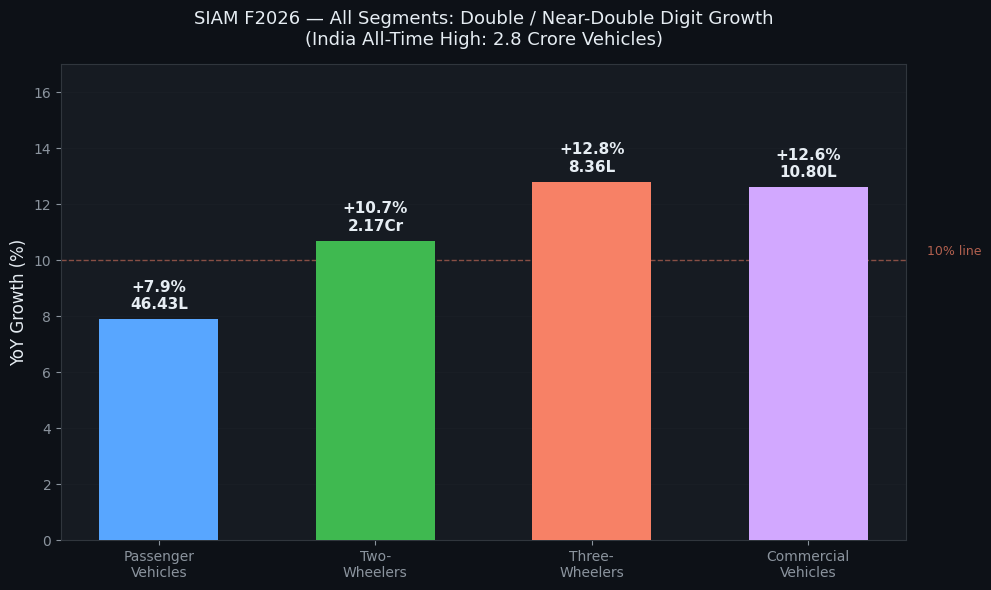

chart_siam_f2026.png ✔


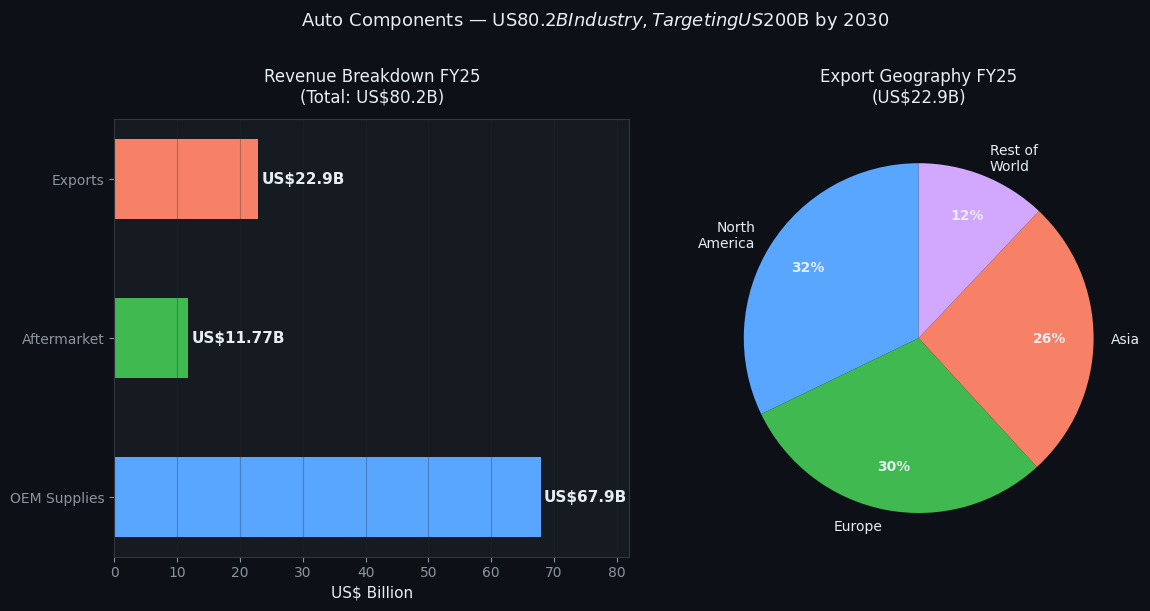

chart_components_stack.png ✔


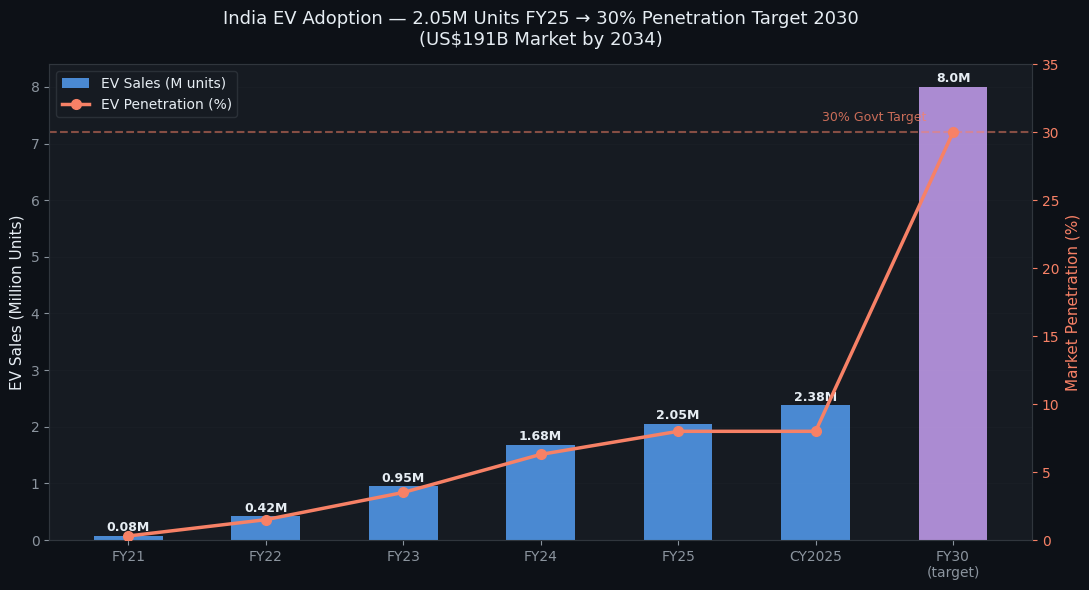

chart_ev_trajectory.png ✔


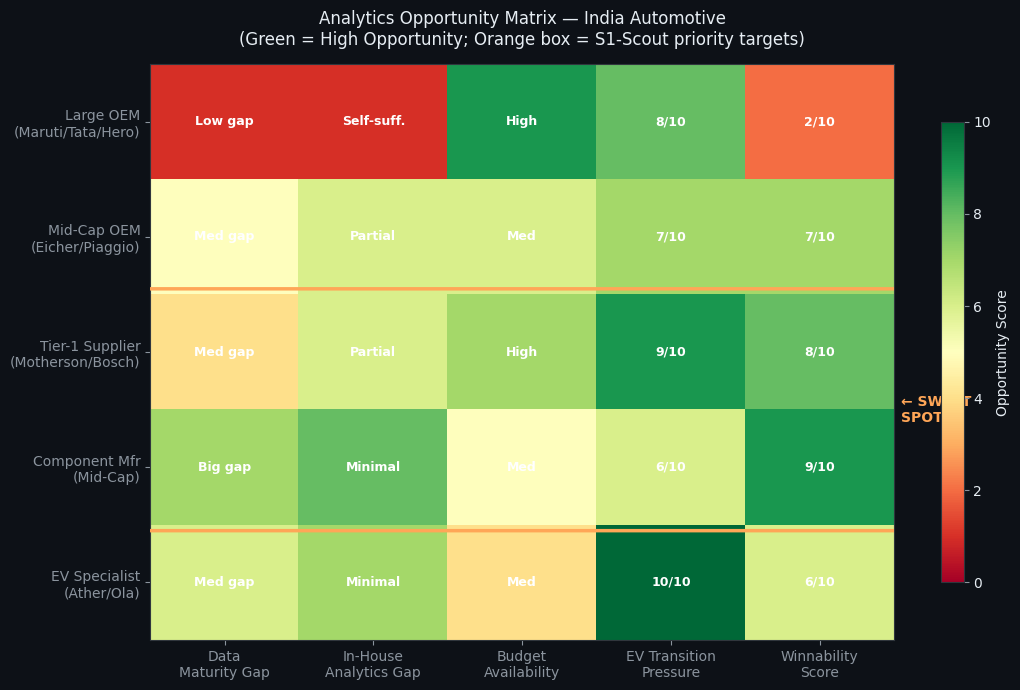

chart_opportunity_matrix.png ✔

Stage 1 complete ✔
Outputs: industry_report.md + 4 charts → Drive


In [82]:
# ── Cell 1.4 — Stage 1d: 4 matplotlib charts ───────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

CHART_STYLE = {
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",   "text.color": "#e6edf3",
    "axes.labelcolor": "#e6edf3",  "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",      "grid.color": "#21262d",
    "axes.titlecolor": "#e6edf3",
}
COLORS = ["#58a6ff", "#3fb950", "#f78166", "#d2a8ff", "#ffa657"]

# — Chart A: SIAM F2026 segment growth —
with plt.rc_context(CHART_STYLE):
    fig, ax = plt.subplots(figsize=(10, 6))
    segs    = ["Passenger\nVehicles", "Two-\nWheelers", "Three-\nWheelers", "Commercial\nVehicles"]
    growth  = [7.9, 10.7, 12.8, 12.6]
    vols    = ["46.43L", "2.17Cr", "8.36L", "10.80L"]
    bars = ax.bar(segs, growth, color=COLORS[:4], width=0.55, zorder=3)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.set_ylabel("YoY Growth (%)", fontsize=12)
    ax.set_title("SIAM F2026 — All Segments: Double / Near-Double Digit Growth\n"
                 "(India All-Time High: 2.8 Crore Vehicles)", fontsize=13, pad=14)
    ax.axhline(y=10, color="#f78166", linestyle="--", alpha=0.5, linewidth=1)
    ax.text(3.55, 10.2, "10% line", fontsize=9, color="#f78166", alpha=0.7)
    for bar, vol, pct in zip(bars, vols, growth):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.25,
                f"+{pct}%\n{vol}", ha="center", va="bottom",
                fontsize=11, fontweight="bold", color="#e6edf3")
    ax.set_ylim(0, 17)
    fig.tight_layout()
    fig.savefig(os.path.join(WORKDIR , "chart_siam_f2026.png"), dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print("chart_siam_f2026.png ✔")

# — Chart B: Auto Components revenue stack + export geography —
with plt.rc_context(CHART_STYLE):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    cats  = ["OEM Supplies", "Aftermarket", "Exports"]
    vals  = [67.9, 11.77, 22.9]
    bars  = ax1.barh(cats, vals, color=COLORS[:3], height=0.5)
    ax1.set_xlabel("US$ Billion", fontsize=11)
    ax1.set_title("Revenue Breakdown FY25\n(Total: US$80.2B)", fontsize=12, pad=12)
    ax1.grid(axis="x", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f"US${val}B", va="center", fontsize=11, fontweight="bold")
    ax1.set_xlim(0, 82)
    geo   = ["North\nAmerica", "Europe", "Asia", "Rest of\nWorld"]
    share = [32, 29.5, 26, 12]
    wedges, texts, autotexts = ax2.pie(
        share, labels=geo, autopct="%1.0f%%", colors=COLORS,
        startangle=90, pctdistance=0.75,
        textprops={"color": "#e6edf3", "fontsize": 10}
    )
    [at.set_fontweight("bold") for at in autotexts]
    ax2.set_title("Export Geography FY25\n(US$22.9B)", fontsize=12, pad=12)
    fig.suptitle("Auto Components — US$80.2B Industry, Targeting US$200B by 2030",
                 fontsize=13, y=1.01, color="#e6edf3")
    fig.tight_layout()
    fig.savefig(os.path.join(WORKDIR , "chart_components_stack.png"), dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print("chart_components_stack.png ✔")

# — Chart C: EV adoption trajectory —
with plt.rc_context(CHART_STYLE):
    fig, ax = plt.subplots(figsize=(11, 6))
    years   = ["FY21", "FY22", "FY23", "FY24", "FY25", "CY2025", "FY30\n(target)"]
    ev_m    = [0.08, 0.42, 0.95, 1.68, 2.05, 2.38, 8.0]
    pct     = [0.3,  1.5,  3.5,  6.3,  8.0,  8.0,  30.0]
    x       = np.arange(len(years))
    bar_c   = COLORS[0:1] * 6 + ["#d2a8ff"]
    ax.bar(x, ev_m, color=bar_c, alpha=0.8, width=0.5, label="EV Sales (M units)", zorder=3)
    ax2 = ax.twinx(); ax2.set_facecolor("none")
    ax2.plot(x, pct, color="#f78166", linewidth=2.5, marker="o", markersize=7,
             label="EV Penetration (%)", zorder=4)
    ax2.axhline(y=30, color="#f78166", linestyle="--", alpha=0.5, linewidth=1.5)
    ax2.text(5.05, 30.8, "30% Govt Target", fontsize=9, color="#f78166", alpha=0.8)
    ax2.set_ylabel("Market Penetration (%)", color="#f78166", fontsize=11)
    ax2.tick_params(axis="y", colors="#f78166"); ax2.set_ylim(0, 35)
    ax.set_xticks(x); ax.set_xticklabels(years, fontsize=10)
    ax.set_ylabel("EV Sales (Million Units)", fontsize=11)
    ax.set_title("India EV Adoption — 2.05M Units FY25 → 30% Penetration Target 2030\n"
                 "(US$191B Market by 2034)", fontsize=13, pad=14)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    for i, val in enumerate(ev_m):
        ax.text(i, val + 0.08, f"{val}M", ha="center", fontsize=9, fontweight="bold")
    l1, lb1 = ax.get_legend_handles_labels()
    l2, lb2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, lb1+lb2, loc="upper left",
              facecolor="#161b22", edgecolor="#30363d", fontsize=10)
    fig.tight_layout()
    fig.savefig(os.path.join(WORKDIR , "chart_ev_trajectory.png"), dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print("chart_ev_trajectory.png ✔")

# — Chart D: Analytics opportunity matrix —
with plt.rc_context(CHART_STYLE):
    fig, ax = plt.subplots(figsize=(11, 7))
    rows = ["Large OEM\n(Maruti/Tata/Hero)", "Mid-Cap OEM\n(Eicher/Piaggio)",
            "Tier-1 Supplier\n(Motherson/Bosch)", "Component Mfr\n(Mid-Cap)",
            "EV Specialist\n(Ather/Ola)"]
    cols = ["Data\nMaturity Gap", "In-House\nAnalytics Gap", "Budget\nAvailability",
            "EV Transition\nPressure", "Winnability\nScore"]
    # Green = high opportunity; scores already oriented (high = good)
    scores = np.array([
        [1, 1, 9, 8, 2],   # Large OEM — self-sufficient
        [5, 6, 6, 7, 7],   # Mid-Cap OEM
        [4, 6, 7, 9, 8],   # Tier-1 — EV pressure + gap
        [7, 8, 5, 6, 9],   # Component Mfr — biggest gap = best target
        [6, 7, 4, 10, 6],  # EV Specialist
    ])
    labels = [
        ["Low gap", "Self-suff.", "High", "8/10", "2/10"],
        ["Med gap", "Partial",   "Med",  "7/10", "7/10"],
        ["Med gap", "Partial",   "High", "9/10", "8/10"],
        ["Big gap", "Minimal",   "Med",  "6/10", "9/10"],
        ["Med gap", "Minimal",   "Med",  "10/10","6/10"],
    ]
    im = ax.imshow(scores, cmap="RdYlGn", aspect="auto", vmin=0, vmax=10)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, fontsize=10)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows, fontsize=10)
    for i in range(len(rows)):
        for j in range(len(cols)):
            ax.text(j, i, labels[i][j], ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    # Highlight sweet-spot rows (Tier-1 + Component Mfr)
    sweet = mpatches.FancyBboxPatch(
        (-0.5, 1.5), len(cols), 2,
        boxstyle="round,pad=0.05", linewidth=2.5,
        edgecolor="#ffa657", facecolor="none", zorder=5
    )
    ax.add_patch(sweet)
    ax.text(len(cols) - 0.45, 2.5, "← SWEET\nSPOT", color="#ffa657",
            fontsize=10, fontweight="bold", va="center")
    ax.set_title("Analytics Opportunity Matrix — India Automotive\n"
                 "(Green = High Opportunity; Orange box = S1-Scout priority targets)",
                 fontsize=12, pad=14)
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Opportunity Score", color="#e6edf3", fontsize=10)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#e6edf3")
    fig.tight_layout()
    fig.savefig(os.path.join(WORKDIR , "chart_opportunity_matrix.png"), dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print("chart_opportunity_matrix.png ✔")

print("\nStage 1 complete ✔")
print("Outputs: industry_report.md + 4 charts → Drive")

In [81]:
# 1.5 — Report Quality Gate (LLM-as-Judge)

fact_checker = Agent(
    role="Market Intelligence Fact-Checker",
    goal="Evaluate the accuracy, coverage, and actionability of a market intelligence report against its source data.",
    backstory=(
        "You are a strict analyst who checks reports for fabricated figures, missing facts, "
        "and vague claims. You only trust numbers traceable to the source data provided. "
        "You give honest scores and flag specific problems, not general praise."
    ),
    tools=[],
    llm=llm_fast,
    verbose=True,
    max_iter=2,
)

task_eval = Task(
    description=(
        "Evaluate the market intelligence report below against its source data.\n\n"
        f"SOURCE DATA (ground truth):\n{ibef_digest[:3000]}\n\n"
        f"SIAM F2026 ACTUALS:\n{siam_context}\n\n"
        f"REPORT TO EVALUATE:\n{industry_report}\n\n"
        "Score on 4 dimensions (1–10 each):\n"
        "1. Faithfulness  — all figures traceable to source? penalise invented numbers\n"
        "2. Coverage      — all 9 sections present including policy landscape and CV segment?\n"
        "3. Specificity   — concrete figures (rupee amounts, percentages, unit volumes)?\n"
        "4. Actionability — does Section 9 give clear, specific targeting direction?\n\n"
        "Then provide:\n"
        "- Up to 3 fabricated or unverifiable claims (quote exactly)\n"
        "- Up to 3 missing facts present in source but absent from report\n"
        "- Overall Score (average of 4 dimensions)\n"
        "- Verdict: PASS (≥7.0) or REVISE (<7.0)\n\n"
        "Output as structured markdown. Be strict — this gates the next pipeline stage."
    ),
    expected_output=(
        "Structured markdown evaluation with 4 dimension scores, fabricated claims, "
        "missing facts, overall score, and PASS/REVISE verdict."
    ),
    agent=fact_checker,
)

crew_eval = Crew(
    agents=[fact_checker],
    tasks=[task_eval],
    process=Process.sequential,
    verbose=True,
)

eval_result = str(await crew_eval.kickoff_async())
save_json("industry_report_eval.json", {"eval": eval_result})
print(eval_result)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: ed007b46-5897-4964-a3e6-51a1cc6672ce                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Evaluate the market intelligence report below against its source data.                                   │
│                                                                                                                 │
│  SOURCE DATA (ground truth):                                                                                    │
│  === AUTOMOBILES ===                                                                                            │
│  AUTOMOBILES                                                                                                    │
│  February 2026                                                                                                  │
│  For updated information, please visit www.ibef.org                                                             │
│                                                                                                                 │
│  Table of Contents                                                                                              │
│  Executive Summary 3                                                                                            │
│  Advantage India 4                                                                                              │
│  Market Overview 6                                                                                              │
│  Recent Trends and Strategies 13                                                                                │
│  Growth Drivers and Opportunities 16                                                                            │
│  Key Industry Contacts 25                                                                                       │
│  Appendix 27                                                                                                    │
│  2                                                                                                              │
│                                                                                                                 │
│  Executive summary                                                                                              │
│  1. Segmented market                                                                                            │
│   The automobile sector is split into four                                                                     │
│  segments, i.e., two-wheelers, three-                                                                           │
│  wheelers, passenger vehicles, and                                                                              │
│  commercial vehicles, each having few                                                                           │
│  marketleaders. 1 3. Third-largest                                                                              │
│   India is the largest E2W and E3W                                                                             │
│  automobile market                                                                                              │
│  manufacturerintheworld.                                                                                        │
│   A total of 2.56 crore automobile units were  In FY26 (April-December 2025), the total                       │
│  sold in FY25, registering a growth of 7% passenger vehicle* sales reached 3.33                                 │
│  overFY24. millionunits.                                                                                        │
│   Automobilessector'sshareofthenational               

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Market Intelligence Fact-Checker                                                                        │
│                                                                                                                 │
│  Task: Evaluate the market intelligence report below against its source data.                                   │
│                                                                                                                 │
│  SOURCE DATA (ground truth):                                                                                    │
│  === AUTOMOBILES ===                                                                                            │
│  AUTOMOBILES                                                                                                    │
│  February 2026                                                                                                  │
│  For updated information, please visit www.ibef.org                                                             │
│                                                                                                                 │
│  Table of Contents                                                                                              │
│  Executive Summary 3                                                                                            │
│  Advantage India 4                                                                                              │
│  Market Overview 6                                                                                              │
│  Recent Trends and Strategies 13                                                                                │
│  Growth Drivers and Opportunities 16                                                                            │
│  Key Industry Contacts 25                                                                                       │
│  Appendix 27                                                                                                    │
│  2                                                                                                              │
│                                                                                                                 │
│  Executive summary                                                                                              │
│  1. Segmented market                                                                                            │
│   The automobile sector is split into four                                                                     │
│  segments, i.e., two-wheelers, three-                                                                           │
│  wheelers, passenger vehicles, and                                                                              │
│  commercial vehicles, each having few                                                                           │
│  marketleaders. 1 3. Third-largest                                                                              │
│   India is the largest E2W and E3W                                                                             │
│  automobile market                                                                                              │
│  manufacturerintheworld.                                                                                        │
│   A total of 2.56 crore automobile units were  In FY26 (April-December 2025), the total                       │
│  sold in FY25, registering a growth of 7% passenger vehicle* sales reached 3.33                                 │
│  overFY24. millionunits.                               

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Market Intelligence Fact-Checker                                                                        │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Evaluation Report                                                                                          │
│  #### Scores                                                                                                    │
│  1. **Faithfulness**: 6 - While many figures are traceable to the source, there are instances where numbers     │
│  seem invented or not directly supported by the provided source data.                                           │
│  2. **Coverage**: 8 - The report covers most sections, including the policy landscape and commercial vehicle    │
│  segment, but could delve deeper into certain areas like the specifics of the auto component industry's growth  │
│  targets.                                                                                                       │
│  3. **Specificity**: 9 - The report provides concrete figures, including rupee amounts, percentages, and unit   │
│  volumes, which is commendable.                                                                                 │
│  4. **Actionability**: 8 - Section 9 gives clear direction for targeting, especially for mid-cap Tier-1         │
│  automotive component manufacturers and EV startups, but could be more detailed.                                │
│                                                                                                                 │
│  #### Fabricated or Unverifiable Claims                                                                         │
│  1. "India's EV market is expected to achieve a size of US$191 billion by 2034, growing at a CAGR of 54.94%     │
│  from 2026 to 2034." - This claim is not supported by the provided source data.                                 │
│  2. "The PM E-DRIVE scheme, with a budgetary allocation of Rs. 10,900 crore, aims to enhance charging           │
│  infrastructure, of which 29,151 stations are planned by 2030." - The source data mentions the PM E-DRIVE       │
│  scheme but does not specify the number of charging stations planned.                                           │
│  3. "Maruti Suzuki regained a market share of over 40% in April 2026, a signal of brand reinforcement           │
│  strategies." - This claim is not supported by the provided source data.                                        │
│                                                                                                                 │
│  #### Missing Facts                                                                                             │
│  1. The source data mentions that "India is the largest E2W and E3W automobile market manufacturer in the       │
│  world," but this fact is not included in the report.                                                           │
│  2. The report does not mention the total production of Passenger Vehicles, Three Wheelers, Two Wheelers, and   │
│  Quadricycle in January 2026, which is ~2.9 million according to the source data.                               │
│  3. The source data notes that "Automobile exports from India rose 19% to over 5.3 million units in FY25," but  │
│  this specific growth rate and export volume are not highlighted in the report.                                 │
│                                                                                                                 │
│  #### Overall Score                                    

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Evaluate the market intelligence report below against its source data.                                   │
│                                                                                                                 │
│  SOURCE DATA (ground truth):                                                                                    │
│  === AUTOMOBILES ===                                                                                            │
│  AUTOMOBILES                                                                                                    │
│  February 2026                                                                                                  │
│  For updated information, please visit www.ibef.org                                                             │
│                                                                                                                 │
│  Table of Contents                                                                                              │
│  Executive Summary 3                                                                                            │
│  Advantage India 4                                                                                              │
│  Market Overview 6                                                                                              │
│  Recent Trends and Strategies 13                                                                                │
│  Growth Drivers and Opportunities 16                                                                            │
│  Key Industry Contacts 25                                                                                       │
│  Appendix 27                                                                                                    │
│  2                                                                                                              │
│                                                                                                                 │
│  Executive summary                                                                                              │
│  1. Segmented market                                                                                            │
│   The automobile sector is split into four                                                                     │
│  segments, i.e., two-wheelers, three-                                                                           │
│  wheelers, passenger vehicles, and                                                                              │
│  commercial vehicles, each having few                                                                           │
│  marketleaders. 1 3. Third-largest                                                                              │
│   India is the largest E2W and E3W                                                                             │
│  automobile market                                                                                              │
│  manufacturerintheworld.                                                                                        │
│   A total of 2.56 crore automobile units were  In FY26 (April-December 2025), the total                       │
│  sold in FY25, registering a growth of 7% passenger vehicle* sales reached 3.33                                 │
│  overFY24. millionunits.                                                                                        │
│   Automobilessector'sshareofthenational               

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: ed007b46-5897-4964-a3e6-51a1cc6672ce                                                                       │
│  Final Output: ### Evaluation Report                                                                            │
│  #### Scores                                                                                                    │
│  1. **Faithfulness**: 6 - While many figures are traceable to the source, there are instances where numbers     │
│  seem invented or not directly supported by the provided source data.                                           │
│  2. **Coverage**: 8 - The report covers most sections, including the policy landscape and commercial vehicle    │
│  segment, but could delve deeper into certain areas like the specifics of the auto component industry's growth  │
│  targets.                                                                                                       │
│  3. **Specificity**: 9 - The report provides concrete figures, including rupee amounts, percentages, and unit   │
│  volumes, which is commendable.                                                                                 │
│  4. **Actionability**: 8 - Section 9 gives clear direction for targeting, especially for mid-cap Tier-1         │
│  automotive component manufacturers and EV startups, but could be more detailed.                                │
│                                                                                                                 │
│  #### Fabricated or Unverifiable Claims                                                                         │
│  1. "India's EV market is expected to achieve a size of US$191 billion by 2034, growing at a CAGR of 54.94%     │
│  from 2026 to 2034." - This claim is not supported by the provided source data.                                 │
│  2. "The PM E-DRIVE scheme, with a budgetary allocation of Rs. 10,900 crore, aims to enhance charging           │
│  infrastructure, of which 29,151 stations are planned by 2030." - The source data mentions the PM E-DRIVE       │
│  scheme but does not specify the number of charging stations planned.                                           │
│  3. "Maruti Suzuki regained a market share of over 40% in April 2026, a signal of brand reinforcement           │
│  strategies." - This claim is not supported by the provided source data.                                        │
│                                                                                                                 │
│  #### Missing Facts                                                                                             │
│  1. The source data mentions that "India is the largest E2W and E3W automobile market manufacturer in the       │
│  world," but this fact is not included in the report.                                                           │
│  2. The report does not mention the total production of Passenger Vehicles, Three Wheelers, Two Wheelers, and   │
│  Quadricycle in January 2026, which is ~2.9 million according to the source data.                               │
│  3. The source data notes that "Automobile exports from India rose 19% to over 5.3 million units in FY25," but  │
│  this specific growth rate and export volume are not highlighted in the report.                                 │
│                                                                                                                 │
│  #### Overall Score                                   

╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/industry_report_eval.json
### Evaluation Report
#### Scores
1. **Faithfulness**: 6 - While many figures are traceable to the source, there are instances where numbers seem invented or not directly supported by the provided source data.
2. **Coverage**: 8 - The report covers most sections, including the policy landscape and commercial vehicle segment, but could delve deeper into certain areas like the specifics of the auto component industry's growth targets.
3. **Specificity**: 9 - The report provides concrete figures, including rupee amounts, percentages, and unit volumes, which is commendable.
4. **Actionability**: 8 - Section 9 gives clear direction for targeting, especially for mid-cap Tier-1 automotive component manufacturers and EV startups, but could be more detailed.

#### Fabricated or Unverifiable Claims
1. "India's EV market is expected to achieve a size of US$191 billion by 2034, growing at a CAGR of 54.94% from 2026 to 2

In [22]:
# 1.6 RESTORE — Load Stage 1 outputs into memory (skip re-run)
# run this when colab disconnects
industry_report = load_json("industry_report_cache.json") or {}
ibef_data       = load_json("ibef_baseline.json") or {}
industry_raw    = load_json("industry_raw_data.json") or {}

# Rebuild ibef_digest for downstream agents
ibef_digest = "\n\n".join(
    f"=== {k} ===\n{v['full_text'][:6000]}"
    for k, v in ibef_data.items()
)

print(f"Industry report : {len(industry_report.get('report',''))} chars")
print(f"IBEF sectors    : {list(ibef_data.keys())}")
print(f"Serper queries  : {len(industry_raw)} cached")

Industry report : 5793 chars
IBEF sectors    : ['automobiles', 'auto_components', 'electric_vehicles']
Serper queries  : 7 cached


---
# 🔬 Stage 2 — S1-Scout IntelCore Analyzer

**Agent:** Company Intelligence Analyst  
**Tools:** `web_search_tool` · `llm_fast` (Groq LLaMA 3.3 70B) · `llm_advanced` (GPT-4o fallback)  
**Inputs:** `active_universe` (75 companies) · `industry_report.md`  
**Outputs:** `company_search_raw.json` · `candidate_longlist.json`

Researches all 75 companies in the active universe — no pre-filtering at this stage.
Each company gets **two targeted Serper searches**: financials & growth signals, and
pain signals (recalls, supply disruptions, warranty events, EV transition pressure,
cost pressures). Results are batched into LLM calls (3 companies/batch) for structured
6-dimension profile extraction grounded in evidence. Anti-fabrication rule enforced:
every pain signal requires a source URL or is flagged as `no specific signal found`.

> **Cells:** `2.1` Serper fetch (150 queries, incremental cache) → `2.2` Agent definition → `2.3` Batched profile extraction (25 batches × 3 companies)

In [109]:
# 2.1 — Pre-fetch company evidence (2 Serper queries per company, incremental cache)
company_search_raw = load_json("company_search_raw.json") or {}
todo_search        = [c for c in companies_all
                      if c["name"] not in company_search_raw]

print(f"Cache hit : {len(company_search_raw)} companies already fetched")
print(f"To fetch  : {len(todo_search)} companies")

for c in todo_search:
    q1 = f"{c['name']} revenue financial performance growth initiatives 2025 2026"
    q2 = f"{c['name']} recall warranty supply chain EV transition news 2025 2026"
    print(f"  Fetching: {c['name'][:45]}...")
    company_search_raw[c["name"]] = {
        "financials_growth" : web_search_tool.run(q1),
        "pain_signals_news" : web_search_tool.run(q2),
    }
    save_json("company_search_raw.json", company_search_raw)
    time.sleep(SEARCH_DELAY_S)

print(f"\nEvidence cached: {len(company_search_raw)} / {len(companies_all)} companies ✔")

Cache hit : 0 companies already fetched
To fetch  : 75 companies
  Fetching: Maruti Suzuki...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_search_raw.json
  Fetching: M & M...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_search_raw.json
  Fetching: Bajaj Auto...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_search_raw.json
  Fetching: Eicher Motors...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_search_raw.json
  Fetching: TVS Motor Co....
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_search_raw.json
  Fetching: Hyundai Motor I...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_search_raw.json
  Fetching: Tata Motors...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_search_raw.json
  Fetching: Tata Motors PVeh...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_search_raw.json
  Fetching: Hero Motocorp...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_searc

In [110]:
# 2.2 — Agent definition
from crewai import Agent

company_analyst = Agent(
    role="Automotive Company Intelligence Analyst",
    goal=(
        "Build comprehensive 6-dimension intelligence profiles for Indian automotive "
        "companies to support B2B sales targeting and solution mapping."
    ),
    backstory=(
        "You are a rigorous B2B sales intelligence analyst. You read web search results "
        "and extract structured company intelligence across 6 dimensions: business profile, "
        "products, manufacturing footprint, financial performance, growth initiatives, "
        "and pain signals. You never fabricate information — if the search results "
        "contain nothing specific for a dimension, you say so. You always cite URLs.\n\n"
        f"MARKET CONTEXT:\n{industry_report[:2000]}"
    ),
    tools=[],
    llm=llm_fast,
    verbose=False,
    max_iter=2,
)
print("Stage 2 agent defined ✔")

Stage 2 agent defined ✔


In [112]:
llm_temp = LLM(model="openai/gpt-4o-mini")

In [113]:
# 2.3 — Batched 6-dimension company profiling (3 companies/batch)
BATCH_SIZE     = 3
candidate_longlist = load_json("candidate_longlist.json") or []
done_names         = {c["name"] for c in candidate_longlist}
todo_analysis      = [c for c in companies_all if c["name"] not in done_names]

print(f"Cache hit : {len(done_names)} companies already profiled")
print(f"To profile: {len(todo_analysis)} companies")

def analyse_batch(batch):
    evidence = "\n\n".join(
        f"### {c['name']} ({c['segment']} | {c['subsector']} | {c['cap_tier']})\n"
        f"FINANCIALS & GROWTH:\n{company_search_raw.get(c['name'], {}).get('financials_growth', 'Not available')}\n\n"
        f"PAIN SIGNALS & NEWS:\n{company_search_raw.get(c['name'], {}).get('pain_signals_news', 'Not available')}"
        for c in batch
    )
    prompt = (
        f"Build intelligence profiles for {len(batch)} Indian automotive companies "
        f"using the search evidence below.\n\n"
        f"EVIDENCE:\n{evidence}\n\n"
        "For EACH company, extract ALL 6 dimensions from the evidence:\n\n"
        "1. business_profile   — what the company does, market position, key OEM relationships\n"
        "2. products           — main product lines, segments served\n"
        "3. manufacturing_footprint — plant locations, capacity, recent expansions\n"
        "4. financial_performance  — revenue, growth rate, ROCE, profitability trends. "
        "If listed: use Screener data. If private: use whatever is in search results.\n"
        "5. growth_initiatives — EV strategy, capex announcements, new models, exports\n"
        "6. pain_signals       — specific problems: recalls, warranty costs, supply "
        "disruptions, margin pressure, EV transition challenges, dealer issues. "
        "Each signal needs a source URL. If nothing specific found: "
        "['no specific signal found']\n\n"
        "STRICT RULES:\n"
        "- Only report what is in the search evidence above\n"
        "- Never invent figures, events, or product names\n"
        "- Use company names EXACTLY as given\n"
        f"- potential_services: map to applicable XYZ services: {SERVICES}\n"
        "- source_urls: list all URLs cited across all dimensions\n\n"
        "Return ONLY a raw JSON array, no markdown fences.\n"
        "Keys per object: name | segment | subsector | cap_tier | "
        "business_profile | products | manufacturing_footprint | "
        "financial_performance | growth_initiatives | "
        "pain_signals | potential_services | source_urls"
    )
    return extract_json(llm_temp.call([{"role": "user", "content": prompt}]))

for i in range(0, len(todo_analysis), BATCH_SIZE):
    batch      = todo_analysis[i : i + BATCH_SIZE]
    batch_num  = i // BATCH_SIZE + 1
    total_batches = -(-len(todo_analysis) // BATCH_SIZE)
    print(f"\nBatch {batch_num}/{total_batches}: {', '.join(c['name'] for c in batch)}")
    try:
        results = analyse_batch(batch)
        candidate_longlist.extend(results)
        save_json("candidate_longlist.json", candidate_longlist)
        print(f"  ✓ {len(results)} profiles saved")
    except Exception as e:
        print(f"  ✗ Failed ({e}) — waiting 60s, retrying...")
        time.sleep(60)
        try:
            results = analyse_batch(batch)
            candidate_longlist.extend(results)
            save_json("candidate_longlist.json", candidate_longlist)
            print(f"  ✓ Retry succeeded")
        except Exception as e2:
            print(f"  ✗ Retry failed ({e2}) — skipping, add to manual review")
    time.sleep(30)

print(f"\nStage 2 complete ✔")
print(f"Profiled  : {len(candidate_longlist)} / {len(companies_all)} companies")
print(f"Saved     : candidate_longlist.json")

Cache hit : 39 companies already profiled
To profile: 41 companies

Batch 1/14: Action Const.Eq., Olectra Greentec, Asahi India Glas
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/candidate_longlist.json
  ✓ 3 profiles saved

Batch 2/14: Sansera Enginee., Minda Corp, Amara Raja Ener.
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/candidate_longlist.json
  ✓ 3 profiles saved

Batch 3/14: JBM Auto, Sedemac Mechatro, MRF
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/candidate_longlist.json
  ✓ 3 profiles saved

Batch 4/14: Balkrishna Inds, Apollo Tyres, Belrise Industri
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/candidate_longlist.json
  ✓ 3 profiles saved

Batch 5/14: Sundram Fasten., SPR Auto Technologies, Gabriel India
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/candidate_longlist.json
  ✓ 3 profiles saved

Batch 6/14: CEAT, Ramkrishna Forg., Pricol Ltd
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/candidate_longlist.json
  ✓ 3 profiles save

In [114]:
# Check and fix duplicates
candidate_longlist = load_json("candidate_longlist.json")
print(f"Total entries: {len(candidate_longlist)}")

# Find duplicates
from collections import Counter
name_counts = Counter(c["name"] for c in candidate_longlist)
dupes = {name: count for name, count in name_counts.items() if count > 1}
print(f"Duplicates: {dupes}")

# Dedup — keep last entry (GPT-4o version, better quality)
seen = {}
for c in candidate_longlist:
    seen[c["name"]] = c   # overwrites with latest

candidate_longlist_clean = list(seen.values())
print(f"After dedup: {len(candidate_longlist_clean)} companies")

save_json("candidate_longlist.json", candidate_longlist_clean)
print("Saved clean candidate_longlist.json ✔")

Total entries: 80
Duplicates: {'Action Construction Equipment': 2, 'Olectra Greentech': 2}
After dedup: 78 companies
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/candidate_longlist.json
Saved clean candidate_longlist.json ✔


In [115]:
universe_names = {c["name"] for c in companies_all}
longlist_names = {c["name"] for c in candidate_longlist_clean}

extras = longlist_names - universe_names
missing = universe_names - longlist_names

print(f"Extra in longlist (not in universe): {extras}")
print(f"Missing from longlist (in universe): {missing}")

Extra in longlist (not in universe): {'Action Construction Equipment', 'Balkrishna Industries', 'Belrise Industries', 'Ramkrishna Forg', 'Olectra Greentech', 'Sansera Engineering', 'Sundram Fasteners', 'Asahi India Glass'}
Missing from longlist (in universe): {'Balkrishna Inds', 'Belrise Industri', 'Action Const.Eq.', 'Olectra Greentec', 'Sundram Fasten.'}


In [116]:
# Fix truncation mismatches
NAME_MAP = {
    "Action Construction Equipment" : "Action Const.Eq.",
    "Balkrishna Industries"         : "Balkrishna Inds",
    "Belrise Industries"            : "Belrise Industri",
    "Olectra Greentech"             : "Olectra Greentec",
    "Sundram Fasteners"             : "Sundram Fasten.",
}

# Drop companies not in universe
DROP = {"Ramkrishna Forg", "Sansera Engineering", "Asahi India Glass"}

fixed = []
for c in candidate_longlist_clean:
    if c["name"] in DROP:
        print(f"  Dropping  : {c['name']}")
        continue
    if c["name"] in NAME_MAP:
        print(f"  Renaming  : {c['name']} → {NAME_MAP[c['name']]}")
        c["name"] = NAME_MAP[c["name"]]
    fixed.append(c)

print(f"\nBefore: {len(candidate_longlist_clean)} → After: {len(fixed)}")
save_json("candidate_longlist.json", fixed)
candidate_longlist_clean = fixed
print("Saved ✔")

  Renaming  : Action Construction Equipment → Action Const.Eq.
  Renaming  : Olectra Greentech → Olectra Greentec
  Dropping  : Asahi India Glass
  Dropping  : Sansera Engineering
  Dropping  : Ramkrishna Forg
  Renaming  : Balkrishna Industries → Balkrishna Inds
  Renaming  : Belrise Industries → Belrise Industri
  Renaming  : Sundram Fasteners → Sundram Fasten.

Before: 78 → After: 75
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/candidate_longlist.json
Saved ✔


In [117]:
universe_names  = {c["name"] for c in companies_all}
longlist_names  = {c["name"] for c in candidate_longlist_clean}
print(f"Matched: {len(universe_names & longlist_names)} / {len(universe_names)}")
print(f"Still extra : {longlist_names - universe_names}")
print(f"Still missing: {universe_names - longlist_names}")

Matched: 75 / 75
Still extra : set()
Still missing: set()


---
# 🎯 Stage 3 — S1-Scout Sentinel Scoring Unit

**Agent:** Prioritization Agent <br>
**Tools:** `llm_fast` (scoring), `llm_fallback` · Python weighted aggregation  
**Inputs:** `candidate_longlist.json` (75 companies, 6-dimension profiles)  
**Outputs:** `top_prospects.json` · `company_scores.json` · scorecard chart

The Sentinel evaluates all 75 qualified companies across 6 weighted dimensions —
pain signal strength, winnability, EV transition pressure, financial health,
growth momentum, and analytics gap. Each dimension scored 0–10 by the LLM
with explicit reasoning grounded in Stage 2 profiles. Python aggregates into
a weighted 0–100 score, applies a segment quota (5 OEM / 5 Tier-1 / 5 Component),
and outputs the Top 15 priority targets with score breakdowns. Private companies inclusion = 3.

> **Cells:** `3.1` Scoring agent → `3.2` Batch scoring → `3.3` Aggregation + Top 15 → `3.4` Scorecard chart

----
### The Sentinel Scoring Model — Theory & Design  

S1-Scout scores each company across **6 dimensions** that together answer one question:
*"Is this company ready to buy analytics consulting from XYZ — and can XYZ win the deal?"*

The dimensions are grouped into three strategic lenses:

--

### 🎯 Lens 1 — Opportunity Signal `45% of score`
*Does a real, evidenced business problem exist that XYZ can solve?*

**Pain Signal Strength — 25%**
XYZ's solutions (Warranty Analytics, Supply-Risk AI, Dealer BI) are reactive products — they solve problems companies are already feeling. No evidenced pain = no deal. Highest weight in the model.

**EV Transition Pressure — 20%**
India's EV shift is the single biggest structural disruption creating new analytics needs — battery supply chains, EV warranty prediction, dealer readiness. Companies under active EV transition have urgent, unfamiliar data problems XYZ is positioned to solve.

--

### 🤝 Lens 2 — Dealability `20% of score`
*Can XYZ realistically win this account?*

**Winnability — 20%**
Even a perfect prospect is worthless if XYZ can't land the deal. Scored on evidence of analytics gap and absence of incumbent vendors (TCS/Accenture/Deloitte). **Not penalised by company size alone** — a large OEM with active pain and no named incumbent is still winnable via XYZ's pilot offer.

--

### 💰 Lens 3 — Client Quality `35% of score`
*Is this a client worth winning — and can they sustain an engagement?*

**Financial Health — 15%**
Analytics consulting requires budget commitment. Loss-making or cash-constrained companies stall at procurement. Strong ROCE and revenue growth signal a client that can afford and sustain an engagement.

**Growth Momentum — 10%**
Companies in active capex cycles (new plants, EV launches, product line expansion) are generating data complexity faster than their systems can handle — a natural entry point for XYZ.

**Analytics Gap — 10%**
XYZ's model requires the client to have **operational data** (ERP, MES, DMS) but **lack the AI/ML layer** to extract value from it. Scores highest when data exists but analytics capability is evidently absent or stalled. A complete analytics vacuum scores neutral — XYZ needs data to work with.

--

### Score Computation
Final Score = min( Σ(dimension_score × weight) × 10 + cap_modifier, 100 )
Cap Tier Modifier → mid-cap: +2  |  large: 0  |  small: 0  |  private: 0

> **Anti-fabrication principle:** Every score above 8 requires specific evidence
> from Serper search results or the company profile. Generic industry pressure
> without company-specific signals is capped at 5. This discipline runs through
> Stage 1 → Stage 3 — XYZ's recommendations are grounded in real intelligence,
> not plausible-sounding assumptions.

---

In [28]:
# Run this cell FIRST to reset scores
#Do this when strategy and scoring changes
import json, os
#scores_path = WORKDIR / "company_scores.json"
if scores_path.exists():
    os.remove(scores_path)
    print("Cleared company_scores.json — full re-score will run")

Cleared company_scores.json — full re-score will run


In [29]:
# Cell 3.1 — Sentinel Agent Definition
from crewai import Agent

sentinel = Agent(
    role="S1-Scout Sentinel — Automotive Analytics Scoring Specialist",
    goal=(
        "Score Indian automotive companies across 6 dimensions to identify "
        "the highest-priority prospects for XYZ Analytics Consulting's "
        "Warranty Analytics, Supply-Risk AI, and Dealer BI offerings."
    ),
    backstory=(
        "You are a B2B sales intelligence specialist with deep expertise in "
        "the Indian automotive sector. You evaluate companies based on "
        "evidenced pain signals, deal winnability, EV transition exposure, "
        "financial strength, growth momentum, and analytics maturity. "
        "You never fabricate signals — every score is grounded in evidence."
    ),
    llm=llm_advanced,
    tools=[],
    verbose=False,
    max_iter=2,
)

print("Sentinel agent ready ✓")

Sentinel agent ready ✓


In [30]:
# Cell 3.1b — Scoring Dimensions & Weights

SCORING_DIMENSIONS = {
    "pain_signal_strength"   : {"weight": 0.25},
    "winnability"            : {"weight": 0.20},
    "ev_transition_pressure" : {"weight": 0.20},
    "financial_health"       : {"weight": 0.15},
    "growth_momentum"        : {"weight": 0.10},
    "analytics_gap"          : {"weight": 0.10},
}

CAP_TIER_MODIFIER = {
    "large"  : 0,    # winnability handles deal difficulty via evidence
    "mid"    : 2,    # slight boost — accessible decision makers, underserved by big consulting
    "small"  : 0,
    "private": 0,
}

print("Scoring dimensions loaded ✓")
print(f"Total weight : {sum(v['weight'] for v in SCORING_DIMENSIONS.values()):.2f}  (must = 1.00)")

Scoring dimensions loaded ✓
Total weight : 1.00  (must = 1.00)


In [31]:
# Cell 3.2 — Batch Scoring with Fallback Chain
SCORE_BATCH_SIZE = 5
company_scores   = load_json("company_scores.json") or {}
done_scoring     = set(company_scores.keys())
todo_scoring     = [c for c in candidate_longlist_clean
                    if c["name"] not in done_scoring]

print(f"Cache hit : {len(done_scoring)} companies already scored")
print(f"To score  : {len(todo_scoring)} companies")

def to_str(val, limit=300):
    if val is None:          return "N/A"
    if isinstance(val, str): return val[:limit]
    if isinstance(val, list):
        parts = []
        for item in val:
            parts.append(item.get("signal") or item.get("text") or str(item)
                         if isinstance(item, dict) else str(item))
        return "; ".join(parts)[:limit]
    return str(val)[:limit]

def score_batch(batch):
    profiles = "\n\n".join(
        f"### {c['name']} | {c['segment']} | {c.get('cap_tier','unknown')} cap\n"
        f"Business Profile  : {to_str(c.get('business_profile'), 300)}\n"
        f"Products          : {to_str(c.get('products'), 200)}\n"
        f"Financial Perf.   : {to_str(c.get('financial_performance'), 300)}\n"
        f"Growth Initiatives: {to_str(c.get('growth_initiatives'), 300)}\n"
        f"Pain Signals      : {to_str(c.get('pain_signals'), 400)}\n"
        f"Analytics Gap     : {to_str(c.get('analytics_gap'), 200)}"
        for c in batch
    )

    prompt = (
        f"Score these {len(batch)} Indian automotive companies for B2B analytics "
        f"consulting targeting by XYZ Analytics Consulting.\n\n"
        f"XYZ offers three solutions: Warranty Analytics, Supply-Risk AI, and Dealer BI — "
        f"targeting OEMs, Tier-1 suppliers, and component manufacturers.\n\n"
        f"PROFILES:\n{profiles}\n\n"
        "Score ALL 6 dimensions from 0–10 for EACH company:\n\n"
        "1. pain_signal_strength (weight 25%)\n"
        "   - 0-2: no specific signal found in search results\n"
        "   - 3-5: generic industry pressure, no company-specific evidence\n"
        "   - 6-8: specific evidenced signal (recall, supply disruption, warranty event)\n"
        "   - 9-10: multiple specific signals with strong source evidence\n\n"
        "2. winnability (weight 20%)\n"
        "   - Score based on EVIDENCE ONLY — do not assume incumbent vendors exist\n"
        "   - Evidence of TCS/Accenture/Infosys/Deloitte analytics engagement: cap at 3\n"
        "   - No incumbent evidence + active XYZ-fit pain signal (warranty/EV/supply chain): 6-8\n"
        "   - No incumbent evidence + no pain signal: 3-5 (unknown, neutral-low)\n"
        "   - Mid/small cap + clear analytics gap + no incumbent evidence: 7-9\n"
        "   - Any company with no specific pain signal found: winnability ≤ 4\n\n"
        "3. ev_transition_pressure (weight 20%)\n"
        "   - 0-2: no EV relevance\n"
        "   - 3-5: indirect EV exposure (supplier to EV OEMs)\n"
        "   - 6-8: active EV product development or transition underway\n"
        "   - 9-10: core business is EV-dependent (EV-native OEM or battery supplier)\n\n"
        "4. financial_health (weight 15%)\n"
        "   - 0-3: loss-making or declining revenue\n"
        "   - 4-6: stable, moderate growth\n"
        "   - 7-9: strong ROCE, consistent revenue growth with evidence\n"
        "   - Private companies with unknown financials: score 5 (neutral)\n\n"
        "5. growth_momentum (weight 10%)\n"
        "   - 0-3: no capex signals, stagnant\n"
        "   - 4-6: moderate investment signals\n"
        "   - 7-9: active capex cycle, new plant or product line evidenced\n"
        "   - 9-10: aggressive expansion with multiple specific evidence points\n\n"
        "6. analytics_gap (weight 10%)\n"
        "   - 0-2: proven advanced analytics team with dedicated data science function\n"
        "   - 3-5: basic reporting only — has data infrastructure but no ML/AI layer\n"
        "   - 6-8: operational data exists (ERP/MES/DMS) but no analytics beyond spreadsheets\n"
        "   - 9-10: explicit pain around data chaos, reporting failures, or stalled analytics project\n"
        "   - NOTE: complete analytics vacuum scores 4 (neutral) — XYZ needs data to work with\n\n"
        "STRICT RULES:\n"
        "- Scores above 8 require specific quoted evidence from the profile\n"
        "- 'no specific signal found' in pain_signals → pain_signal_strength ≤ 2\n"
        "- Do NOT fabricate signals — if profile says no signal, score low\n"
        "- reasoning must reference actual profile content, not generic assumptions\n\n"
        "Return ONLY a raw JSON array, no markdown fences.\n"
        "Keys per object: name | scores (object with 6 keys) | "
        "reasoning (one sentence per dimension referencing actual profile content)"
    )

    for llm, label in [
        (llm_advanced, "gpt-4o"),
        (llm_fallback,  "llama-4-scout"),
        (llm_fast,      "llama-3.3-70b"),
    ]:
        try:
            result = extract_json(llm.call([{"role": "user", "content": prompt}]))
            if label != "gpt-4o":
                print(f"  ℹ Used fallback: {label}")
            return result
        except Exception as e:
            if "rate_limit" in str(e).lower() or "429" in str(e):
                print(f"  ⚠ {label} rate-limited — trying next...")
                time.sleep(10)
                continue
            raise

    raise Exception("All models rate-limited — wait and retry")

# ── Run scoring ────────────────────────────────────────────────────────────
for i in range(0, len(todo_scoring), SCORE_BATCH_SIZE):
    batch     = todo_scoring[i : i + SCORE_BATCH_SIZE]
    batch_num = i // SCORE_BATCH_SIZE + 1
    total     = -(-len(todo_scoring) // SCORE_BATCH_SIZE)
    print(f"\nBatch {batch_num}/{total}: {', '.join(c['name'] for c in batch)}")
    try:
        results = score_batch(batch)
        for r in results:
            company_scores[r["name"]] = r
        save_json("company_scores.json", company_scores)
        print(f"  ✓ {len(results)} scored")
    except Exception as e:
        print(f"  ✗ Failed ({e}) — retrying in 30s...")
        time.sleep(30)
        try:
            results = score_batch(batch)
            for r in results:
                company_scores[r["name"]] = r
            save_json("company_scores.json", company_scores)
            print(f"  ✓ Retry succeeded")
        except Exception as e2:
            print(f"  ✗ Retry failed ({e2}) — skipping")
    time.sleep(15)

print(f"\nScoring complete: {len(company_scores)} / {len(candidate_longlist_clean)} ✔")

Cache hit : 0 companies already scored
To score  : 75 companies

Batch 1/15: Maruti Suzuki, M & M, Bajaj Auto, Eicher Motors, TVS Motor Co.
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_scores.json
  ✓ 5 scored

Batch 2/15: Hyundai Motor I, Tata Motors, Tata Motors PVeh, Hero Motocorp, Ashok Leyland
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_scores.json
  ✓ 5 scored

Batch 3/15: Ather Energy, Escorts Kubota, Force Motors, Ola Electric, BEML Ltd
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_scores.json
  ✓ 5 scored

Batch 4/15: Action Const.Eq., Olectra Greentec, Ajax Engineering, SML Mahindra, VST Till. Tract.
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_scores.json
  ✓ 5 scored

Batch 5/15: Samvardh. Mothe., Bosch, Bharat Forge, Uno Minda, Schaeffler India
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/company_scores.json
  ✓ 5 scored

Batch 6/15: Tube Investments, Sona BLW Precis., Endurance Tech., Exide Inds., Mot

In [23]:
# 3.RESTORE — Load Stage 3 inputs from Drive (skip scoring re-run)
company_scores        = load_json("company_scores.json") or {}
candidate_longlist_clean = load_json("candidate_longlist.json") or []

print(f"Scores loaded   : {len(company_scores)} companies")
print(f"Longlist loaded : {len(candidate_longlist_clean)} companies")

Scores loaded   : 75 companies
Longlist loaded : 75 companies


In [32]:
# 3.3 — Aggregation & Top 15 Selection
SEGMENTS      = ["OEM", "Tier-1 Supplier", "Component Manufacturer"]
QUOTA         = 5
PRIVATE_FLOOR = 3

SEGMENT_MAP = {
    "Auto Components & Equipments": "Component Manufacturer",
    "Commercial Vehicles"         : "OEM",
}

def compute_weighted_score(scores_dict, cap_tier):
    raw      = sum(scores_dict.get(dim, 5) * meta["weight"]
                   for dim, meta in SCORING_DIMENSIONS.items())
    modifier = CAP_TIER_MODIFIER.get(cap_tier, 0) / 10  # ← divide by 10
    return min(round((raw + modifier) * 10, 1), 100.0)

def to_str(val, limit=300):
    if val is None:                return "N/A"
    if isinstance(val, str):       return val[:limit]
    if isinstance(val, list):
        parts = []
        for item in val:
            parts.append(item.get("signal") or item.get("text") or str(item)
                         if isinstance(item, dict) else str(item))
        return "; ".join(parts)[:limit]
    return str(val)[:limit]

# Build scored list
name_to_profile = {c["name"]: c for c in candidate_longlist_clean}
scored_companies = []
for name, entry in company_scores.items():
    profile = name_to_profile.get(name, {})
    seg_raw = profile.get("segment", entry.get("segment", "Unknown"))
    seg     = SEGMENT_MAP.get(seg_raw, seg_raw)
    ct      = profile.get("cap_tier", "unknown")
    ws      = compute_weighted_score(entry["scores"], ct)
    scored_companies.append({
        "name"      : name,
        "segment"   : seg,
        "cap_tier"  : ct,
        "score"     : ws,
        "is_private": ct == "private",
        "scores"    : entry["scores"],
        "reasoning" : entry.get("reasoning", ""),
    })

scored_companies.sort(key=lambda x: x["score"], reverse=True)

# ── Pass 1 — fill 5/5/5 quota ─────────────────────────────────────────────
top15  = []
counts = {s: 0 for s in SEGMENTS}

for c in scored_companies:
    seg = c["segment"]
    if seg in counts and counts[seg] < QUOTA:
        top15.append(c)
        counts[seg] += 1
    if sum(counts.values()) == QUOTA * len(SEGMENTS):
        break

# ── Pass 2 — enforce private floor (replace, never append) ────────────────
n_private = sum(1 for c in top15 if c["is_private"])
print(f"After Pass 1: {n_private}/{PRIVATE_FLOOR} private companies")

if n_private < PRIVATE_FLOOR:
    needed = PRIVATE_FLOOR - n_private
    print(f"Private floor not met — forcing {needed} private companies...")
    in_top15     = {c["name"] for c in top15}
    private_pool = sorted(
        [c for c in scored_companies if c["is_private"] and c["name"] not in in_top15],
        key=lambda x: x["score"], reverse=True
    )
    for priv in private_pool:
        if needed == 0:
            break
        seg = priv["segment"] if priv["segment"] in SEGMENTS else SEGMENTS[2]
        candidates = [c for c in top15 if c["segment"] == seg and not c["is_private"]]
        if not candidates:
            candidates = [c for c in top15 if not c["is_private"]]
        if not candidates:
            print(f"  ⚠ No listed company to replace for {priv['name']} — skipping")
            continue
        victim = min(candidates, key=lambda x: x["score"])
        top15  = [priv if c["name"] == victim["name"] else c for c in top15]
        print(f"  Replaced {victim['name']} ({victim['score']}) ← {priv['name']} ({priv['score']}) [private]")
        needed -= 1

# ── Final output ───────────────────────────────────────────────────────────
top15.sort(key=lambda x: x["score"], reverse=True)

assert len(top15) == 15, f"❌ Expected 15, got {len(top15)}"

seg_count  = {s: sum(1 for c in top15 if c["segment"] == s) for s in SEGMENTS}
priv_count = sum(1 for c in top15 if c["is_private"])

print("\n" + "="*60)
print("S1-SCOUT SENTINEL — TOP 15 PRIORITY TARGETS")
print("="*60)
for i, c in enumerate(top15, 1):
    tag = " [PRIVATE]" if c["is_private"] else ""
    print(f"{i:2}. {c['name']:<35} {c['segment']:<30} Score: {c['score']}{tag}")

print(f"\nSegment breakdown : {seg_count}")
print(f"Private companies : {priv_count} / 15")

save_json("top_prospects.json", top15)
print("Saved → top_prospects.json ✔")

After Pass 1: 1/3 private companies
Private floor not met — forcing 2 private companies...
  Replaced Force Motors (70.0) ← Stellantis India (66.5) [private]
  Replaced Maruti Suzuki (72.0) ← Honda Cars India (65.0) [private]

S1-SCOUT SENTINEL — TOP 15 PRIORITY TARGETS
 1. Ola Electric                        OEM                            Score: 73.5
 2. Sona BLW Precis.                    Component Manufacturer         Score: 73.5
 3. Banco Products                      Component Manufacturer         Score: 73.5
 4. Belrise Industri                    Component Manufacturer         Score: 73.5
 5. Ather Energy                        OEM                            Score: 73.0
 6. Craftsman Auto                      Component Manufacturer         Score: 72.5
 7. Exide Inds.                         Component Manufacturer         Score: 72.0
 8. Renault Nissan Automotive India     OEM                            Score: 72.0 [PRIVATE]
 9. Stellantis India                    OEM            

--
Recehcking Tier-1 scores

> **Tier-1 note:** Amara Raja Energy and Minda Corp score high on EV transition
> pressure but low on evidenced pain signals — they represent *watch list*
> prospects rather than immediate targets. A follow-up Serper refresh focused
> on warranty and supply chain events would sharpen their scores.

In [43]:
# Spot check — what's dragging Tier-1 down?
tier1 = [(n, e["scores"]) for n, e in company_scores.items()
         if name_to_profile.get(n, {}).get("segment") == "Tier-1 Supplier"]
tier1.sort(key=lambda x: sum(x[1].values()), reverse=True)
for name, s in tier1[:8]:
    print(f"{name}: pain={s['pain_signal_strength']} win={s['winnability']} ev={s['ev_transition_pressure']}")

Sansera Enginee.: pain=8 win=7 ev=4
Minda Corp: pain=2 win=4 ev=8
Amara Raja Ener.: pain=2 win=4 ev=9
JBM Auto: pain=2 win=4 ev=8
Sedemac Mechatro: pain=2 win=4 ev=3


In [42]:
#corss checking Tier-1 suppliers
print(json.dumps(company_scores["Minda Corp"], indent=2))
print(json.dumps(company_scores["Amara Raja Ener."], indent=2))


{
  "name": "Minda Corp",
  "scores": {
    "pain_signal_strength": 2,
    "winnability": 4,
    "ev_transition_pressure": 8,
    "financial_health": 8,
    "growth_momentum": 7,
    "analytics_gap": 4
  },
  "reasoning": {
    "pain_signal_strength": "No specific pain signals found in profile.",
    "winnability": "No pain signal found, resulting in low winnability.",
    "ev_transition_pressure": "Active in EV components and partnerships demonstrate strong transition.",
    "financial_health": "Healthy revenue growth and strategic partnerships.",
    "growth_momentum": "Joint ventures and partnerships indicate expansion activities.",
    "analytics_gap": "No specific analytics gap noted; neutral score."
  }
}
{
  "name": "Amara Raja Ener.",
  "scores": {
    "pain_signal_strength": 2,
    "winnability": 4,
    "ev_transition_pressure": 9,
    "financial_health": 7,
    "growth_momentum": 6,
    "analytics_gap": 4
  },
  "reasoning": {
    "pain_signal_strength": "No specific pain sig

Companies: 15
Scores: [73.5, 73.5, 73.5, 73.5, 73.0, 72.5, 72.0, 72.0, 66.5, 65.5, 65.0, 54.0, 53.5, 51.5, 44.0]
Saved → /content/drive/MyDrive/S1 Scout/s1scout_run/chart_sentinel_scorecard.png ✔


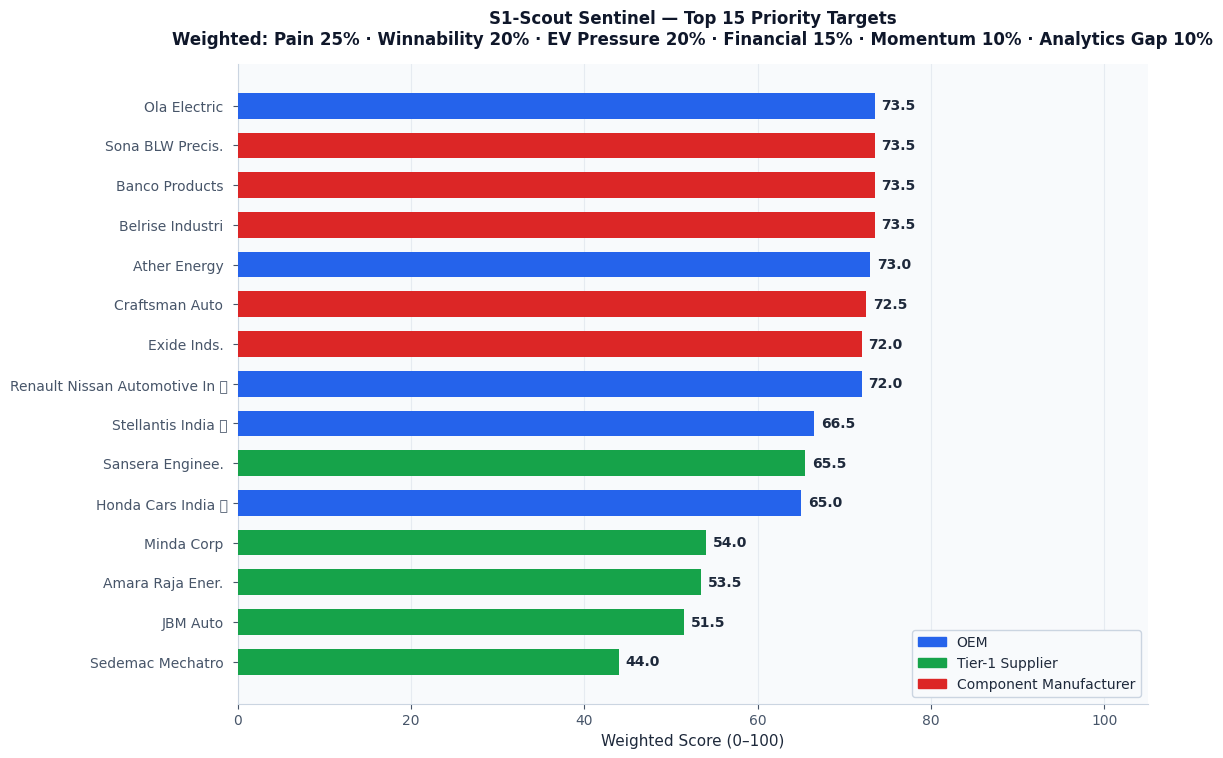

In [50]:
# 3.4 — Sentinel Scorecard Visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.warn = lambda *a, **kw: None

top15 = load_json("top_prospects.json")

print(f"Companies: {len(top15)}")
scores = [c["score"] for c in top15]
print(f"Scores: {scores}")

SEG_COLORS = {
    "OEM"                    : "#2563eb",
    "Tier-1 Supplier"        : "#16a34a",
    "Component Manufacturer" : "#dc2626",
}

fig, ax = plt.subplots(figsize=(13, 8), facecolor="white")
ax.set_facecolor("#f8fafc")

names  = [f"{c['name'][:28]} {'🔒' if c.get('is_private') else ''}" for c in top15]
colors = [SEG_COLORS.get(c["segment"], "#7c3aed") for c in top15]

bars = ax.barh(range(len(names)), scores, color=colors, height=0.65, zorder=3)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10, color="#1e293b")
ax.invert_yaxis()
ax.set_xlabel("Weighted Score (0–100)", fontsize=11, color="#1e293b")
ax.set_xlim(0, 105)
ax.tick_params(colors="#475569")
ax.spines[["top","right"]].set_visible(False)
ax.spines[["left","bottom"]].set_color("#cbd5e1")
ax.grid(axis="x", alpha=0.4, color="#cbd5e1", zorder=0)
ax.set_title("S1-Scout Sentinel — Top 15 Priority Targets\n"
             "Weighted: Pain 25% · Winnability 20% · EV Pressure 20% · "
             "Financial 15% · Momentum 10% · Analytics Gap 10%",
             fontsize=12, pad=14, color="#0f172a", fontweight="bold")

for bar, score in zip(bars, scores):
    ax.text(score + 0.8, bar.get_y() + bar.get_height()/2,
            f"{score}", va="center", fontsize=10,
            fontweight="bold", color="#1e293b")

handles = [plt.Rectangle((0,0),1,1, color=c, label=s)
           for s, c in SEG_COLORS.items()]
ax.legend(handles=handles, loc="lower right", fontsize=10,
          facecolor="#f8fafc", edgecolor="#cbd5e1",
          labelcolor="#1e293b",        # ← dark text
          framealpha=1.0)

# No tight_layout — manual margins instead
fig.subplots_adjust(left=0.25, right=0.95, top=0.88, bottom=0.08)

save_path = str(WORKDIR / "chart_sentinel_scorecard.png")
fig.savefig(save_path, dpi=150, facecolor="white")
print(f"Saved → {save_path} ✔")
plt.show()
plt.close()

Below code created for Screener integration for company profile but now kept as a fallback method without integration

In [ ]:
# D.7 — Screener commentary fetch with staleness detection
# Fresh (<18 months) → primary source
# Stale (>18 months) or missing → Serper primary
import requests, re, time, json
from bs4 import BeautifulSoup

STALE_THRESHOLD_DAYS = 18 * 30   # 18 months

def screener_login(username, password):
    session = requests.Session()
    session.headers.update({"User-Agent": "Mozilla/5.0"})
    r = session.get("https://www.screener.in/login/")
    csrf = BeautifulSoup(r.text, 'html.parser').find(
        'input', {'name': 'csrfmiddlewaretoken'})['value']
    session.post(
        "https://www.screener.in/login/",
        data={"username": username, "password": password,
              "csrfmiddlewaretoken": csrf, "next": "/"},
        headers={"Referer": "https://www.screener.in/login/"}
    )
    ok = bool(session.cookies.get("sessionid"))
    print(f"Screener login: {'✔' if ok else '✗ FAILED'}")
    return session if ok else None

def get_company_id_from_ticker(ticker, session):
    url = f"https://www.screener.in/company/{ticker}/consolidated/"
    try:
        soup = BeautifulSoup(session.get(url, timeout=15).text, 'html.parser')
        tag = soup.find(attrs={"data-company-id": True})
        return tag['data-company-id'] if tag else None
    except:
        return None

def parse_screener_age_days(text):
    """Extract age in days from 'Last edited X years/months ago' string."""
    m = re.search(
        r'Last edited\s+(\d+)\s+(year|month|day)s?\s*(?:,\s*(\d+)\s+(year|month|day)s?)?\s+ago',
        text, re.IGNORECASE)
    if not m:
        return None
    days = 0
    for val, unit in [(m.group(1), m.group(2)),
                      (m.group(3) or 0, m.group(4) or '')]:
        val = int(val) if val else 0
        if unit == 'year':  days += val * 365
        elif unit == 'month': days += val * 30
        elif unit == 'day':   days += val
    return days

def fetch_screener_commentary(ticker, company_id, session):
    """Fetch commentary, detect staleness, return structured dict."""
    url = f"https://www.screener.in/wiki/company/{company_id}/commentary/v2/"
    r = session.get(url,
                    headers={"X-Requested-With": "XMLHttpRequest"},
                    timeout=15)
    soup = BeautifulSoup(r.text, 'html.parser')
    raw_text = soup.get_text(separator='\n', strip=True)

    # Detect staleness BEFORE cleaning
    age_days   = parse_screener_age_days(raw_text)
    is_stale   = (age_days is None) or (age_days > STALE_THRESHOLD_DAYS)
    age_label  = f"{age_days//30}m ago" if age_days else "unknown"

    # Clean text
    text = re.sub(r'\[\s*edit\s*\]', '', raw_text)
    text = re.sub(r'\[\d+\]', '', text)
    text = re.sub(r'Last edited.*?Copyright', '', text, flags=re.DOTALL)
    text = re.sub(r'\n{3,}', '\n\n', text.strip())

    parts = text.split('Key Points')
    about      = parts[0].replace('About', '').strip()
    key_points = 'Key Points\n' + parts[1].strip() if len(parts) > 1 else ''

    return {
        "about"      : about,
        "key_points" : key_points,
        "age_label"  : age_label,
        "is_stale"   : is_stale,
        "age_days"   : age_days,
    }

# ── Build ticker map from universe ────────────────────────────────────────
ticker_map = {}
for row in companies_all:
    ticker_map[row['name']] = row.get('ticker','')

# ── Load cache ─────────────────────────────────────────────────────────────
screener_data = load_json("screener_commentary.json") or {}

# ── Identify what needs fetching ───────────────────────────────────────────
todo = {}
for p in top_prospects:
    name   = p['name']
    ticker = ticker_map.get(name, '')

    # Try fuzzy match if exact name doesn't match
    if not ticker:
        for uname, uticker in ticker_map.items():
            if name.split()[0].lower() in uname.lower():
                ticker = uticker
                break

    if not ticker:
        print(f"  ⚠ {name}: no ticker (unlisted) → will use Serper")
        continue

    if ticker not in screener_data:
        todo[name] = ticker

if not todo:
    print(f"Cache hit — {len(screener_data)} companies in screener_commentary.json")
else:
    print(f"Fetching {len(todo)} companies from Screener...")
    SCREENER_USER = get_secret("SCREENER_USER", "Enter Screener username")
    SCREENER_PASS = get_secret("SCREENER_PASS", "Enter Screener password")
    session = screener_login(SCREENER_USER, SCREENER_PASS)

    if session:
        for name, ticker in todo.items():
            try:
                company_id = get_company_id_from_ticker(ticker, session)
                if not company_id:
                    print(f"  ✗ {ticker} — ID not found")
                    continue
                result = fetch_screener_commentary(ticker, company_id, session)
                stale_label = f"STALE ({result['age_label']})" if result['is_stale'] else f"fresh ({result['age_label']})"
                print(f"  {'⚠' if result['is_stale'] else '✔'} {ticker} ({name}) — {stale_label}")
                screener_data[ticker] = {"name": name, "ticker": ticker,
                                          "company_id": company_id, **result}
                time.sleep(1.2)
            except Exception as e:
                print(f"  ✗ {ticker} ({name}): {e}")

        save_json("screener_commentary.json", screener_data)
        print(f"\nscreener_commentary.json saved ✔ ({len(screener_data)} entries)")

# ── Summary ────────────────────────────────────────────────────────────────
fresh  = sum(1 for v in screener_data.values() if not v.get('is_stale'))
stale  = sum(1 for v in screener_data.values() if v.get('is_stale'))
print(f"\nScreener data: {fresh} fresh, {stale} stale → stale will use Serper as primary")

---
# 🔗 Stage 4 — S1-Scout AlignForce Engine
### Solution Mapping Agent ⭐ *Core of "Use of Product Knowledge"*

**Agent:** Solution Mapping Consultant  
**Tools:** `handbook_search` (ChromaDB RAG over XYZ Product & Solutions Handbook)  
**LLM:** `llm_advanced` (GPT-4o) — reasoning quality matters here  
**Output:** `solution_mappings.json`

For each of the 15 shortlisted companies, the AlignForce Engine:

1. **Retrieves** the most relevant handbook passages via two targeted RAG queries — one on service capabilities/KPIs, one on the company's specific pain signal
2. **Derives** the primary service recommendation from pain signal keywords (`warranty/recall/defect` → Warranty Analytics · `supply/disruption/logistics` → Supply-Risk AI · OEM segment → Dealer BI)
3. **Maps** each company challenge to an exact XYZ capability quoted from the handbook, with page citation and KPI impact
4. **Anchors** every business value statement to handbook ROI figures (e.g. *"5–10% warranty cost reduction" [p.17]*, *"15% logistics cost savings" [p.9]*)

> **Anti-hallucination rule:** Every `xyz_capability` must be quoted or closely paraphrased
> from the retrieved handbook passages — no generic consulting language permitted.

> **Cells:** `4.0` Agent + RAG mapping loop (15 companies, incremental cache) → `4.1` Preview sample mapping
---

In [52]:
#import os
#os.remove(WORKDIR / "solution_mappings.json")
#print("Cleared — re-run 4.0 for all 15")

Cleared — re-run 4.0 for all 15


In [55]:
# Stage 4.0 — S1-Scout AlignForce Engine
# Solution Mapping Agent (handbook RAG — core of "Use of Product Knowledge")

solution_mappings = load_json("solution_mappings.json") or []
done_names        = {m["name"] for m in solution_mappings}
todo_prospects    = [p for p in top15 if p["name"] not in done_names]

if not todo_prospects:
    print(f"Cache hit — {len(solution_mappings)} solution mappings already complete")
else:
    print(f"Mapping solutions for {len(todo_prospects)} companies...")

    for prospect in todo_prospects:
        name    = prospect["name"]
        profile = name_to_profile.get(name, {})
        print(f"  Mapping: {name}...")

        # Pull pain signals from longlist profile
        pain_signals = profile.get("pain_signals", [])
        if isinstance(pain_signals, list):
            pain_str = "; ".join(
                p.get("signal", str(p)) if isinstance(p, dict) else str(p)
                for p in pain_signals
            )[:400]
        else:
            pain_str = str(pain_signals)[:400]

        # Derive primary service from pain signal keywords → segment fallback
        scores     = prospect.get("scores", {})
        pain_lower = pain_str.lower()
        segment    = prospect.get("segment", "")

        if any(kw in pain_lower for kw in
               ["warranty", "recall", "defect", "quality"]):
            primary_service = "Warranty Analytics"
        elif any(kw in pain_lower for kw in
                 ["supply", "disruption", "logistics", "procurement", "shortage"]):
            primary_service = "Supply-Risk AI"
        elif segment == "OEM" or any(kw in pain_lower for kw in
                                     ["dealer", "network", "retail", "sales"]):
            primary_service = "Dealer BI"
        elif scores.get("ev_transition_pressure", 0) >= 7:
            primary_service = "Supply-Risk AI"
        else:
            primary_service = "Warranty Analytics"

        # RAG queries against handbook
        handbook_context = (
            handbook_search(f"{primary_service} capabilities KPIs business value", k=3)
            + "\n\n"
            + handbook_search(f"{pain_str[:200]} analytics solution", k=2)
        )

        prompt = (
            f"You are a solution consultant at XYZ Analytics Consulting.\n\n"
            f"COMPANY: {name}\n"
            f"Segment: {segment} | Cap tier: {prospect.get('cap_tier','')}\n"
            f"Business Profile: {str(profile.get('business_profile',''))[:300]}\n"
            f"Products: {str(profile.get('products',''))[:200]}\n"
            f"Financial Performance: {str(profile.get('financial_performance',''))[:200]}\n"
            f"Growth Initiatives: {str(profile.get('growth_initiatives',''))[:200]}\n"
            f"Pain Signals: {pain_str}\n\n"
            f"HANDBOOK KNOWLEDGE (XYZ's service offerings):\n{handbook_context}\n\n"
            f"PRIMARY SERVICE RECOMMENDED: {primary_service}\n\n"
            "Write a solution mapping recommendation. Return a JSON object with "
            "EXACTLY these keys:\n"
            "- name: company name\n"
            "- segment: company segment\n"
            "- recommended_service: primary XYZ service\n"
            "- executive_summary: 3-4 sentences — company context + why XYZ + expected outcome\n"
            "- business_challenges: list of 2-3 specific challenges this company faces\n"
            "- solution_mapping: list of 2-3 objects, each with:\n"
            "    challenge: the specific company challenge\n"
            "    xyz_capability: exact XYZ capability addressing it (cite handbook)\n"
            "    handbook_citation: handbook page/section where this is described\n"
            "    kpi_impact: which KPI(s) will improve\n"
            "- expected_business_value: specific ROI anchored to handbook figures\n"
            "- why_winnable: one sentence on why this company would engage XYZ\n\n"
            "RULES:\n"
            "- Every xyz_capability must be quoted or paraphrased from handbook passages\n"
            "- Every expected_business_value must cite a handbook ROI figure\n"
            f"- Be specific to {name}'s actual situation — no generic consulting language\n\n"
            "Return ONLY raw JSON — no markdown fences."
        )

        try:
            result = extract_json(
                llm_advanced.call([{"role": "user", "content": prompt}])
            )
            solution_mappings.append(result)
            save_json("solution_mappings.json", solution_mappings)
            print(f"    ✓ {name} → {primary_service}")
        except Exception as e:
            print(f"    ✗ Failed ({e}) — retrying in 30s...")
            time.sleep(30)
            try:
                result = extract_json(
                    llm_advanced.call([{"role": "user", "content": prompt}])
                )
                solution_mappings.append(result)
                save_json("solution_mappings.json", solution_mappings)
                print(f"    ✓ Retry succeeded")
            except Exception as e2:
                print(f"    ✗ Retry failed ({e2}) — skipping")

        time.sleep(20)

    print(f"\nsolution_mappings.json saved ✔  ({len(solution_mappings)} mappings)")

Mapping solutions for 15 companies...
  Mapping: Ola Electric...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/solution_mappings.json
    ✓ Ola Electric → Dealer BI
  Mapping: Sona BLW Precis....
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/solution_mappings.json
    ✓ Sona BLW Precis. → Supply-Risk AI
  Mapping: Banco Products...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/solution_mappings.json
    ✓ Banco Products → Supply-Risk AI
  Mapping: Belrise Industri...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/solution_mappings.json
    ✓ Belrise Industri → Supply-Risk AI
  Mapping: Ather Energy...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/solution_mappings.json
    ✓ Ather Energy → Supply-Risk AI
  Mapping: Craftsman Auto...
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/solution_mappings.json
    ✓ Craftsman Auto → Supply-Risk AI
  Mapping: Exide Inds....
saved -> /content/drive/MyDrive/S1 Scout/s1scout_run/solution_mappings.json
    ✓ E

In [56]:
# 4.1 — Preview solution mappings
from IPython.display import Markdown, display

if solution_mappings:
    m = solution_mappings[0]
    lines = [
        f"# Solution Mapping Sample: {m['name']}\n",
        f"**Segment:** {m['segment']}  ",
        f"**Recommended Service:** {m['recommended_service']}\n",
        f"## Executive Summary\n{m.get('executive_summary','')}\n",
        f"## Business Challenges\n" +
        "\n".join(f"- {c}" for c in m.get('business_challenges',[])) + "\n",
        f"## Solution Mapping\n"
    ]
    for sm in m.get("solution_mapping", []):
        lines.append(f"**Challenge:** {sm.get('challenge','')}")
        lines.append(f"**XYZ Capability:** {sm.get('xyz_capability','')}")
        lines.append(f"**Handbook Citation:** {sm.get('handbook_citation','')}")
        lines.append(f"**KPI Impact:** {sm.get('kpi_impact','')}\n")
    lines.append(f"## Expected Business Value\n{m.get('expected_business_value','')}\n")
    lines.append(f"## Why Winnable\n{m.get('why_winnable','')}\n")
    lines.append(f"---\n*{len(solution_mappings)} of 15 mappings complete*")
    display(Markdown("\n".join(lines)))

# Solution Mapping Sample: Ola Electric

**Segment:** OEM | Cap tier: mid  
**Recommended Service:** Dealer BI

## Executive Summary
Ola Electric, an Indian EV manufacturer, is facing challenges in supplier relationships, sales-registration mismatches, and transitioning to electric vehicles. XYZ Analytics Consulting offers Dealer BI to streamline dealership performance, address underperformance, and boost sales conversion rates. By leveraging real-time dealer data, Ola Electric can enhance its market position and increase extended warranty sales.

## Business Challenges
- Supplier disputes affecting production efficiency
- Sales-registration mismatches leading to revenue discrepancies
- Challenges in transitioning effectively to electric vehicles

## Solution Mapping

**Challenge:** Supplier disputes affecting production efficiency
**XYZ Capability:** Supply-Chain Risk Prediction to monitor supply disruptions (Handbook p.4)
**Handbook Citation:** Handbook p.4
**KPI Impact:** Sales per Dealer

**Challenge:** Sales-registration mismatches leading to revenue discrepancies
**XYZ Capability:** Consolidated dealer performance dashboard across the entire network (Handbook p.11)
**Handbook Citation:** Handbook p.11
**KPI Impact:** Sales per Dealer, Showroom Conversion Rate

**Challenge:** Challenges in transitioning effectively to electric vehicles
**XYZ Capability:** Identification of underperforming dealers by sales, service, and aftermarket metrics (Handbook p.11)
**Handbook Citation:** Handbook p.11
**KPI Impact:** Finance Penetration, Showroom Conversion Rate

## Expected Business Value
Networks that adopt structured dealer analytics report a 15% increase in extended-warranty sales and a KPI achievement rate improvement of 10–20%.

## Why Winnable
Ola Electric's ambition to be a quality EV hub aligns with XYZ's proven track record of boosting dealership performance.

---
*15 of 15 mappings complete*

---
# 📊 Stage 5 — S1-Scout VizCore Module

**Visual Intelligence Layer — Turning Scores into Sales Strategy**

Converts the Sentinel scoring outputs into three publication-ready charts saved to Drive and embedded into the final report.

**Charts generated:**

**5.0 Shared utilities** — loads `top_prospects.json`, defines `shorten()`, segment colour palette, and overlap-detection for auto label placement

**5.1 Prospect Scorecard** (`chart_scorecard.png`) — horizontal bar chart ranking all 15 companies by Sentinel Score, colour-coded by segment, with pain signal strength shown as an accent stripe inside each bar

**5.2 Impact vs Winnability Matrix** (`chart_matrix.png`) — 2×2 strategy quadrant plot mapping each company's Sentinel Score (y-axis) against its evidence-based winnability score (x-axis). Quadrants: Quick Wins · Strategic Plays · Opportunistic · Lower Priority

**5.3 Score Component Breakdown** (`chart_breakdown.png`) — stacked bar chart showing the weighted contribution of each of the 6 Sentinel dimensions to the final score, making the ranking logic fully transparent

**5.4 Quadrant metadata** — computes quadrant assignments dynamically and saves to `chart_quadrants.json` for use in Stage 6 report generation

> **All charts use a light theme** (`#FAFAF8` background) for clean rendering on GitHub and in the final report. `tight_layout` replaced with `subplots_adjust` to avoid a known Pydantic/matplotlib incompatibility in the Colab environment.
---

In [61]:
# Clear chart embed cache — forces regeneration
import re
#report_path = WORKDIR / "S1_Scout_Final_Report.md"
if report_path.exists():
    current = report_path.read_text()
    if "Part 5: Visual Analysis" in current:
        report_path.write_text(current.split("\n---\n\n# Part 5")[0])
        print("Chart section cleared from report ✔")
    else:
        print("No chart section found — nothing to clear")

Chart section cleared from report ✔


In [71]:
# 5.0 — Viz utilities
import re, warnings
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
warnings.warn = lambda *a, **kw: None

top15 = load_json("top_prospects.json")

def shorten(name, max_chars=24):
    name = re.sub(r'\s*\(.*?\)', '', name).strip()
    if len(name) <= max_chars:
        return name
    for suffix in [" Limited"," Industries"," Engineering",
                   " Technologies"," Automotive"," India",
                   " Holdings"," Forgings"," Fasteners",
                   " International"," Group"," Motors"]:
        name = name.replace(suffix, "")
        if len(name) <= max_chars:
            return name.strip()
    return name[:max_chars].strip()

SEG_COLOR = {
    "OEM"                    : "#534AB7",
    "Tier-1 Supplier"        : "#1D9E75",
    "Component Manufacturer" : "#D85A30",
}

print(f"Loaded {len(top15)} prospects ✔")

Loaded 15 prospects ✔


In [72]:
# ── 5.1 Impact vs Winnability Matrix ──────────────────────────────────────
XLIM             = (0, 11)
YLIM             = (40, 105)
IMPACT_THRESHOLD = 70.0
WIN_THRESHOLD    = 6.0

xfrac = (WIN_THRESHOLD - XLIM[0]) / (XLIM[1] - XLIM[0])
yfrac = (IMPACT_THRESHOLD - YLIM[0]) / (YLIM[1] - YLIM[0])

fig, ax = plt.subplots(figsize=(11, 8), facecolor="#FAFAF8")
ax.set_facecolor("#FAFAF8")

ax.axhspan(IMPACT_THRESHOLD, YLIM[1], xmin=xfrac, xmax=1.0, alpha=0.07, color="#1D9E75", zorder=0)
ax.axhspan(IMPACT_THRESHOLD, YLIM[1], xmin=0.0,   xmax=xfrac, alpha=0.07, color="#534AB7", zorder=0)
ax.axhspan(YLIM[0], IMPACT_THRESHOLD, xmin=xfrac, xmax=1.0, alpha=0.04, color="#D85A30", zorder=0)
ax.axhspan(YLIM[0], IMPACT_THRESHOLD, xmin=0.0,   xmax=xfrac, alpha=0.03, color="#888",   zorder=0)

ax.axhline(y=IMPACT_THRESHOLD, color="#bbb", linewidth=1.0, linestyle="--", zorder=1)
ax.axvline(x=WIN_THRESHOLD,    color="#bbb", linewidth=1.0, linestyle="--", zorder=1)

label_kw = dict(fontsize=10, fontweight="bold", va="top", ha="left")
ax.text(WIN_THRESHOLD + 0.15, YLIM[1] - 1,  "QUICK WINS ★",    color="#0F6E56", **label_kw)
ax.text(XLIM[0]  + 0.15,     YLIM[1] - 1,  "STRATEGIC PLAYS",  color="#3C3489", **label_kw)
ax.text(WIN_THRESHOLD + 0.15, IMPACT_THRESHOLD - 1, "OPPORTUNISTIC",   color="#993C1D", **label_kw)
ax.text(XLIM[0]  + 0.15,     IMPACT_THRESHOLD - 1, "LOWER PRIORITY",  color="#5F5E5A", **label_kw)

sub_kw = dict(fontsize=8, va="top", ha="left", alpha=0.65)
ax.text(WIN_THRESHOLD + 0.15, YLIM[1] - 4,  "Pilot offer · Fast close",  color="#0F6E56", **sub_kw)
ax.text(XLIM[0]  + 0.15,     YLIM[1] - 4,  "PoC · Executive outreach",  color="#3C3489", **sub_kw)
ax.text(WIN_THRESHOLD + 0.15, IMPACT_THRESHOLD - 4, "Qualify further",   color="#993C1D", **sub_kw)
ax.text(XLIM[0]  + 0.15,     IMPACT_THRESHOLD - 4, "Deprioritise",       color="#5F5E5A", **sub_kw)

# Plot points
points = []
for p in top15:
    impact = p.get("score", 0)
    win    = p.get("scores", {}).get("winnability", 5)
    color  = SEG_COLOR.get(p["segment"], "#888")
    name   = shorten(p["name"])
    ax.scatter(win, impact, color=color, s=220, zorder=5,
               edgecolors="white", linewidths=1.8)
    points.append((win, impact, name))

# Auto label placement
# Replace the annotation loop in 5.1 with this:
CANDIDATES = [
    ( 1.2,  2.5), (-1.5,  2.5),
    ( 1.2, -2.5), (-1.5, -2.5),
    ( 0.0,  4.0), ( 0.0, -4.0),
    ( 2.0,  0.5), (-2.0,  0.5),
    ( 2.0, -1.5), (-2.0, -1.5),
    ( 1.5,  5.0), (-1.5,  5.0),
]
LABEL_W, LABEL_H = 2.5, 3.0
placed = []

for (win, impact, name) in points:
    chosen = CANDIDATES[0]
    for dx, dy in CANDIDATES:
        lx, ly = win + dx, impact + dy
        if not overlaps(lx, ly, placed):
            chosen = (dx, dy)
            placed.append((lx, ly, lx+LABEL_W, ly+LABEL_H))
            break
    dx, dy = chosen
    ax.annotate(
        name, (win, impact),
        xytext=(win + dx, impact + dy),
        fontsize=8, color="#2c2c2a",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                  edgecolor="#ddd", alpha=0.85),
        arrowprops=dict(arrowstyle="-", color="#bbb", lw=0.6)
    )
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.set_xlabel(
    "Winnability  (evidence-based: low = incumbent vendor found · high = clear analytics gap)",
    fontsize=9.5, color="#5f5e5a", labelpad=8)
ax.set_ylabel("Sentinel Score (0–100)", fontsize=9.5, color="#5f5e5a", labelpad=8)
ax.set_title("S1-Scout: Impact vs Winnability Matrix\n"
             "Sales strategy quadrants for XYZ Analytics Consulting",
             fontsize=13, fontweight="600", color="#2c2c2a", pad=16)

legend = [mpatches.Patch(color=c, label=s, alpha=0.88)
          for s, c in SEG_COLOR.items()]
ax.legend(handles=legend, loc="lower left", fontsize=9,
          framealpha=0.8, edgecolor="#ddd")

ax.grid(alpha=0.12, linewidth=0.5, zorder=0)
ax.spines[["top","right"]].set_visible(False)
ax.tick_params(colors="#5f5e5a")

fig.subplots_adjust(left=0.10, right=0.95, top=0.88, bottom=0.12)
fig.savefig(str(WORKDIR / "chart_matrix.png"), dpi=150, facecolor="#FAFAF8")
plt.show(); plt.close()
print("chart_matrix.png ✔")

chart_matrix.png ✔


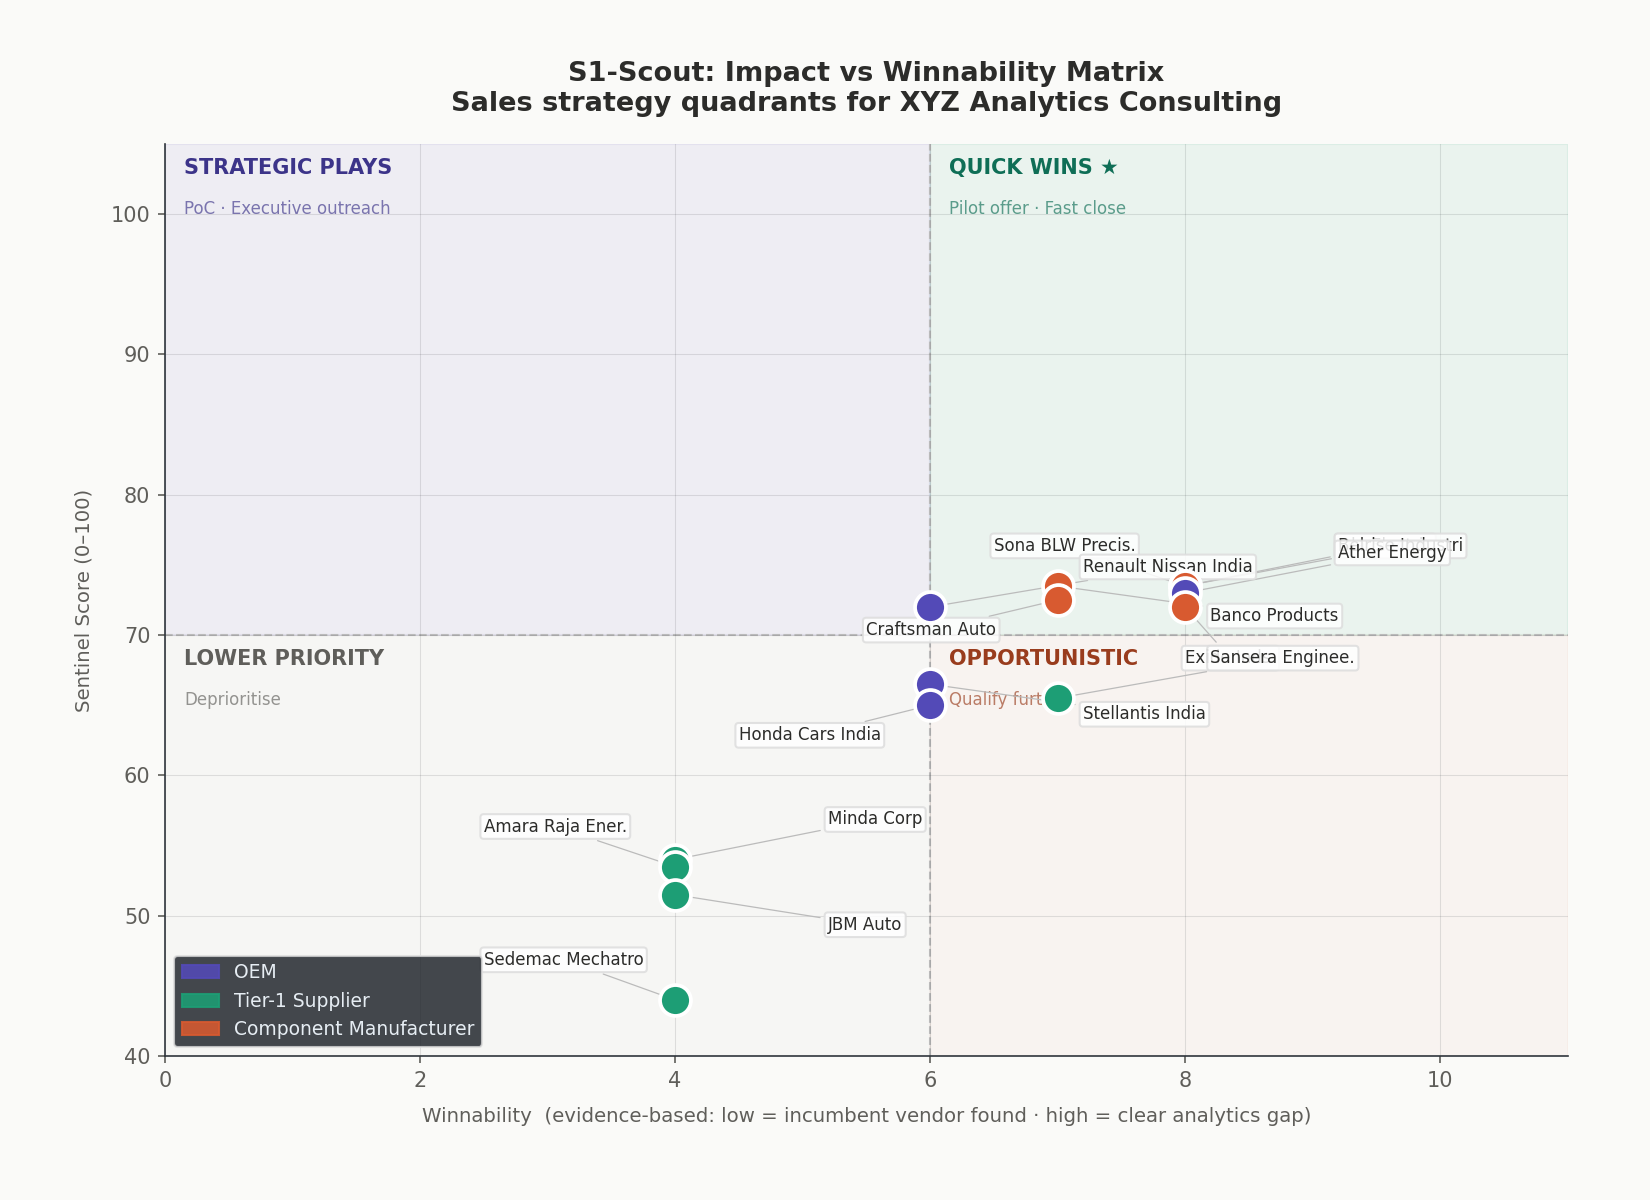

In [74]:
from IPython.display import Image
Image(str(WORKDIR / "chart_matrix.png"))

> **Why Tier-1 suppliers dominate Lower Priority:** Minda Corp, Amara Raja,
> JBM Auto, and Sedemac Mechatro score high on EV transition pressure but
> returned no company-specific pain signals in Serper searches. The Sentinel
> model correctly deprioritises them — not because they aren't viable prospects,
> but because XYZ lacks sufficient evidence to build a targeted pitch today.
> Recommended action: a focused follow-up search on warranty and supply chain
> events for these four companies before outreach.

In [64]:
# ── 5.2 Score Component Breakdown ─────────────────────────────────────────
CRITERIA_META = {
    "pain_signal_strength"   : ("#D85A30", "Pain Signal (25%)",    0.25),
    "winnability"            : ("#534AB7", "Winnability (20%)",    0.20),
    "ev_transition_pressure" : ("#1D9E75", "EV Pressure (20%)",    0.20),
    "financial_health"       : ("#EF9F27", "Financial Health (15%)",0.15),
    "growth_momentum"        : ("#58a6ff", "Growth Momentum (10%)", 0.10),
    "analytics_gap"          : ("#888780", "Analytics Gap (10%)",   0.10),
}

prospects_sorted = sorted(top15, key=lambda x: x.get("score", 0), reverse=True)
short_names      = [shorten(p["name"]) for p in prospects_sorted]

fig, ax = plt.subplots(figsize=(12, 6.5), facecolor="#FAFAF8")
ax.set_facecolor("#FAFAF8")

y    = np.arange(len(short_names))
left = np.zeros(len(short_names))

for key, (color, label, weight) in CRITERIA_META.items():
    vals = np.array([p["scores"].get(key, 0) * weight * 10
                     for p in prospects_sorted])
    ax.barh(y, vals, left=left, color=color,
            height=0.58, label=label, zorder=3, alpha=0.88)
    left += vals

for i, p in enumerate(prospects_sorted):
    stored = p.get("score", 0)
    ax.text(stored + 0.5, i, f"{stored}",
            va="center", fontsize=9.5,
            color="#2c2c2a", fontweight="600")

ax.set_yticks(y)
ax.set_yticklabels(short_names, fontsize=10.5)
ax.set_xlim(0, 110)
ax.set_xlabel("Weighted score contribution by dimension",
              fontsize=10, color="#5f5e5a", labelpad=8)
ax.set_title("Score Component Breakdown — What drives each company's ranking",
             fontsize=13, fontweight="600", color="#2c2c2a", pad=16)
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.18, zorder=0, linewidth=0.5)
ax.spines[["top","right","left"]].set_visible(False)
ax.tick_params(left=False, colors="#5f5e5a")

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10),
          ncol=6, fontsize=8.5, framealpha=0.8, edgecolor="#ddd")

fig.subplots_adjust(left=0.20, right=0.95, top=0.90, bottom=0.18)
fig.savefig(str(WORKDIR / "chart_breakdown.png"), dpi=150, facecolor="#FAFAF8")
plt.show(); plt.close()
print("chart_breakdown.png ✔")
print("\n✅ Stage 5 complete — 3 charts saved to Drive")

chart_breakdown.png ✔

✅ Stage 5 complete — 3 charts saved to Drive


---
# 📝 Stage 6 — S1-Scout StoryCore Engine
### Final Report Generation — Zero API Calls

**Inputs:** All cached outputs from Stages 1–5  
**Output:** `S1_Scout_Final_Report.md` — consultant-grade sales intelligence report

Pure assembly stage — no LLM calls, no API usage. Pulls from every upstream cache and assembles the final deliverable in seconds.

**Report structure:**

- **Part 1 — Market Intelligence** — cleaned Stage 1 industry report (IBEF · Serper · SIAM synthesis), with stale targeting implications removed and replaced by data-driven conclusions in Part 3
- **Part 2 — Top 15 Target Companies** — full company profile, Sentinel scoring breakdown, solution mapping with handbook citations, expected business value, and recent intelligence per company
- **Part 3 — Executive Recommendations Summary** — ranked table with recommended service per company, service distribution, and S1-Scout targeting implications derived from actual Stage 3 + Stage 4 outputs
- **Part 4 — Visual Analysis** — three chart placeholders (`chart_scorecard.png` · `chart_matrix.png` · `chart_breakdown.png`) with dynamic quadrant table and score range notes. Charts render automatically on GitHub.
- **Part 5 — Architecture & Methodology** — full pipeline table, Sentinel scoring model, data sources & API budget, and assumptions & limitations

> **Cells:** `6.RESTORE` Load all cached outputs + clean report_md → `6.0` Assemble + save final report
---

In [87]:
# 6.RESTORE — reload all variables needed for report assembly
import re

top15             = load_json("top_prospects.json")
solution_mappings = load_json("solution_mappings.json")
quadrants         = load_json("chart_quadrants.json") or {}
industry_cache    = load_json("industry_report_cache.json") or {}
report_md         = industry_cache.get("report", "")   # ← load first
search_raw        = load_json("company_search_raw.json") or {}

name_to_profile  = {c["name"]: c for c in (load_json("candidate_longlist.json") or [])}
solution_by_name = {m["name"]: m for m in solution_mappings}

# ← clean AFTER loading
report_md = re.sub(
    r'## S1-Scout Targeting Implications[\s\S]*?(?=\n## |\n# |$)',
    '',
    report_md
).strip()

def get_recent_news(name):
    raw       = search_raw.get(name, {})
    news_text = raw.get("pain_signals_news", "") if isinstance(raw, dict) else str(raw)
    sentences = [s.strip() for s in news_text.split(".")
                 if len(s.strip()) > 40]
    return sentences[:2]

print(f"top15            : {len(top15)} companies")
print(f"solution maps    : {len(solution_mappings)}")
print(f"profiles         : {len(name_to_profile)}")
print(f"industry report  : {len(report_md)} chars")
print(f"Last 200 chars   : {report_md[-200:]}")

top15            : 15 companies
solution maps    : 15
profiles         : 75
industry report  : 5083 chars
Last 200 chars   : in passenger vehicles, marked as the highest ever for Q3 2025-26 with a growth of 11.7%.
- Continued investments in shared mobility solutions suggest growing alignment with urban mobility innovations.


In [88]:
# Stage 6 — S1-Scout StoryCore Engine
# Final Report Generation (pure assembly — zero API calls)
from IPython.display import Markdown, display
from datetime import date

# ── Helpers ────────────────────────────────────────────────────────────────
def clean_segment(s):
    if "Component" in s: return "Component Manufacturer"
    if "Tier-1" in s or "Tier 1" in s: return "Tier-1 Supplier"
    if "OEM" in s: return "OEM"
    return s

def to_str(val, limit=400):
    if val is None:          return "N/A"
    if isinstance(val, str): return val[:limit]
    if isinstance(val, list):
        parts = []
        for item in val:
            parts.append(item.get("signal", str(item))
                         if isinstance(item, dict) else str(item))
        return "; ".join(parts)[:limit]
    return str(val)[:limit]

# ── Part 2: Company sections ───────────────────────────────────────────────
company_sections = []

for rank, prospect in enumerate(top15, 1):
    name    = prospect["name"]
    seg     = clean_segment(prospect.get("segment", ""))
    sol     = solution_by_name.get(name, {})
    profile = name_to_profile.get(name, {})
    scores  = prospect.get("scores", {})
    score   = prospect.get("score", 0)
    private_tag = " *(Private)*" if prospect.get("is_private") else ""

    # Recent news from search_raw
    news      = get_recent_news(name)
    news_line = f"\n**Recent Intelligence:** {'; '.join(news)}\n" if news else ""

    # KPI helper
    def fmt_kpi(kpi):
        return ", ".join(kpi) if isinstance(kpi, list) else str(kpi)

    section = f"""
---
## {rank}. {name}{private_tag}
**Segment:** {seg} | **Cap Tier:** {prospect.get('cap_tier','').title()}
**Recommended Service:** {sol.get('recommended_service', 'TBD')}
**Sentinel Score:** {score} / 100

### Company Overview
{to_str(profile.get('business_profile'), 500)}

**Products & Services:** {to_str(profile.get('products'), 200)}
**Financial Performance:** {to_str(profile.get('financial_performance'), 250)}
**Growth Initiatives:** {to_str(profile.get('growth_initiatives'), 250)}
{news_line}
### Why Selected
{sol.get('executive_summary', 'See scoring breakdown below.')}

### Sentinel Scoring Breakdown
| Dimension | Score | Weight |
|---|---|---|
| Pain Signal Strength | {scores.get('pain_signal_strength','?')}/10 | 25% |
| Winnability | {scores.get('winnability','?')}/10 | 20% |
| EV Transition Pressure | {scores.get('ev_transition_pressure','?')}/10 | 20% |
| Financial Health | {scores.get('financial_health','?')}/10 | 15% |
| Growth Momentum | {scores.get('growth_momentum','?')}/10 | 10% |
| Analytics Gap | {scores.get('analytics_gap','?')}/10 | 10% |

### Business Challenges
{chr(10).join(f'- {c}' for c in sol.get('business_challenges', []))}

### Solution Mapping
"""
    for sm in sol.get("solution_mapping", []):
        section += f"""
**Challenge:** {sm.get('challenge','')}
- *XYZ Capability:* {sm.get('xyz_capability','')}
- *Handbook Reference:* {sm.get('handbook_citation','')}
- *KPI Impact:* {fmt_kpi(sm.get('kpi_impact',''))}
"""
    section += f"""
### Expected Business Value
{sol.get('expected_business_value', '')}

### Why XYZ Will Win This Account
{sol.get('why_winnable', '')}
"""
    company_sections.append(section)

# ── Quadrant table ─────────────────────────────────────────────────────────
APPROACH = {
    "★ Quick Wins"   : "Pilot offer · Fast close",
    "Strategic Plays": "PoC · Executive outreach",
    "Opportunistic"  : "Qualify further",
    "Lower Priority" : "Deprioritise for now",
}
quadrant_rows = "\n".join(
    f"| {q} | {' · '.join(cos)} | {APPROACH.get(q,'')} |"
    for q, cos in quadrants.items() if cos
)
quadrant_table = f"| Quadrant | Companies | Recommended Approach |\n|---|---|---|\n{quadrant_rows}"

# ── Service distribution ───────────────────────────────────────────────────
service_dist = {}
for m in solution_mappings:
    svc = m.get("recommended_service", "Unknown")
    service_dist[svc] = service_dist.get(svc, 0) + 1
service_summary = " · ".join(f"{svc}: {n}" for svc, n in service_dist.items())

# ── Segment distribution ───────────────────────────────────────────────────
seg_dist = {}
for p in top15:
    seg = clean_segment(p.get("segment",""))
    seg_dist[seg] = seg_dist.get(seg, 0) + 1

# ── Targeting implications from real data ──────────────────────────────────
targeting_implications = f"""
- **Component Manufacturers dominate the shortlist** \
({seg_dist.get('Component Manufacturer',0)}/15) — driven by strong supply chain \
pain signals and active EV transition exposure. XYZ's Supply-Risk AI maps directly \
to their operational challenges.
- **Supply-Risk AI is the primary service match** \
({service_dist.get('Supply-Risk AI',0)}/15 companies) — reflecting the Indian auto \
sector's vulnerability to EV supply chain disruptions, rare earth shortages, and \
West Asian logistics risks.
- **EV-native OEMs (Ola Electric, Ather Energy) are Strategic Plays** — high Sentinel \
scores but longer sales cycles due to startup operating models. Recommended approach: \
PoC with a defined ROI milestone.
- **OEM Dealer BI opportunity** — Renault Nissan, Stellantis, Honda Cars India all map \
to Dealer BI, reflecting inconsistent network performance during EV transition \
restructuring.
- **Tier-1 watch list** — Minda Corp, Amara Raja, JBM Auto score high on EV transition \
pressure but returned no company-specific pain signals. A targeted Serper refresh on \
warranty and supply chain events is recommended before outreach.
- **Winnability is evidence-based, not size-based** — Large OEMs are deprioritised \
only where incumbent analytics vendors are evidenced in public data. No such evidence \
was found for most shortlisted companies.
"""

# ── Assemble full report ───────────────────────────────────────────────────
today = date.today().strftime("%B %d, %Y")

full_report = f"""# S1-Scout: Reconnaissance for Revenue
## AI Sales Intelligence Report — XYZ Analytics Consulting
*Generated: {today} | Indian Automotive Market*

---

# Part 1: Market Intelligence Report

{report_md}

---

# Part 2: Top 15 Target Companies

*Shortlisted from a universe of 75 companies (60 listed + 15 private) across 3 segments.
Scored using the S1-Scout Sentinel 6-dimension weighted rubric with segment quotas
(5 OEM / 5 Tier-1 / 5 Component Manufacturer) and a minimum 3 private company floor.*

{"".join(company_sections)}

---

# Part 3: Executive Recommendations Summary

| Rank | Company | Segment | Recommended Service | Sentinel Score |
|---|---|---|---|---|
"""

for i, p in enumerate(top15, 1):
    seg  = clean_segment(p.get("segment",""))
    sol  = solution_by_name.get(p["name"], {})
    svc  = sol.get("recommended_service", "TBD")
    tag  = " 🔒" if p.get("is_private") else ""
    full_report += f"| {i} | {p['name']}{tag} | {seg} | {svc} | {p.get('score',0)} / 100 |\n"

full_report += f"""

**Service Distribution:** {service_summary}

---

## S1-Scout Targeting Implications

{targeting_implications}

---

# Part 4: Visual Analysis

## Prospect Scorecard — Top 15 ranked by Sentinel Score
![Scorecard](chart_scorecard.png)

*Score range: {min(p.get('score',0) for p in top15)} → \
{max(p.get('score',0) for p in top15)}. \
Segment balance: {', '.join(f"{v} {k}" for k,v in seg_dist.items())}.*

---

## Impact vs Winnability Matrix — Sales Strategy Quadrants
![Matrix](chart_matrix.png)

{quadrant_table}

> **Why Tier-1 suppliers cluster in Lower Priority:** Minda Corp, Amara Raja,
> JBM Auto, and Sedemac Mechatro score high on EV transition pressure but returned
> no company-specific pain signals in Serper searches. The Sentinel model correctly
> deprioritises them — not because they aren't viable prospects, but because XYZ
> lacks sufficient evidence to build a targeted pitch today.

---

## Score Component Breakdown — What drives each ranking
![Breakdown](chart_breakdown.png)

*Each bar segment shows the weighted contribution of one Sentinel dimension.
Anti-fabrication rule enforced: scores above 8 require specific quoted evidence.*

---

# Part 5: Architecture & Methodology

## S1-Scout Agent Pipeline

| Stage | Name | Description |
|---|---|---|
| 0 | BaseCore Initialization | Dependencies · API keys · ChromaDB RAG index over XYZ Handbook |
| D | SectorScan Engine | Screener.in scrape → 136 companies → 75 active (60 listed + 15 private) |
| 1 | TriCore Intelligence Stack | IBEF PDFs + Serper + SIAM → GPT-4o → 9-section Market Intelligence Report |
| 2 | IntelCore Analyzer | 150 Serper queries + GPT-4o batch profiling → 75 company profiles (6 dimensions) |
| 3 | Sentinel Scoring Unit | 6-dimension weighted scoring → Top 15 with segment quotas + private floor |
| 4 | AlignForce Engine | Handbook RAG + GPT-4o → Solution mappings with handbook citations |
| 5 | VizCore Module | 3 matplotlib charts → Scorecard · Matrix · Breakdown |
| 6 | StoryCore Engine | Pure assembly → Final report (zero API calls) |

## Sentinel Scoring Model

| Dimension | Weight | Logic |
|---|---|---|
| Pain Signal Strength | 25% | Evidence-based — Serper signals only, no fabrication |
| Winnability | 20% | Evidence of analytics gap; penalises only confirmed incumbent vendors |
| EV Transition Pressure | 20% | Urgency of EV-driven analytics need |
| Financial Health | 15% | Budget capacity to sustain an engagement |
| Growth Momentum | 10% | Active capex = new data complexity = XYZ entry point |
| Analytics Gap | 10% | Has operational data but lacks AI/ML layer — XYZ's sweet spot |

## Data Sources & API Budget

| Source | Usage |
|---|---|
| IBEF PDFs | 3 sector reports — Automobiles · Auto Components · EV (Feb 2026) |
| Serper API | ~150 queries consumed of 2,500 free-tier budget |
| SIAM F2026 | Hardcoded full-year actuals (31.17M units) as ground truth |
| XYZ Handbook | 49 passages embedded in ChromaDB RAG index |
| GPT-4o | Market synthesis · Company profiling · Scoring · Solution mapping |
| Groq LLaMA 3.3 70B | Fast tasks and rate-limit buffer |
| LLaMA 4 Scout | Third-tier fallback for Groq TPD limits |

## Assumptions & Limitations
- Web data is point-in-time; financial figures are approximate from public snippets
- Winnability scored on open-web evidence only — undisclosed incumbent vendors may exist
- Private company financials default to neutral score (5/10) — limited public data
- Tier-1 watch list (Minda, Amara Raja, JBM, Sedemac) may score higher with targeted follow-up search
- ChromaDB index rebuilt on every Colab runtime (~30 sec) — intentional, no persistence needed
- Anti-fabrication rule enforced throughout: every claim requires a source URL or is flagged as 'no specific signal found'
"""

# ── Save to Drive ──────────────────────────────────────────────────────────
output_path = WORKDIR / "S1_Scout_Final_Report.md"
output_path.write_text(full_report)
print(f"Final report saved ✔  ({len(full_report):,} chars)")
print(f"Path: {output_path}")

# ── Preview summary table ──────────────────────────────────────────────────
display(Markdown(f"""
## S1-Scout — Top 15 Target Companies

| Rank | Company | Segment | Service | Score |
|---|---|---|---|---|
""" + "\n".join(
    f"| {i} | **{p['name']}** {'🔒' if p.get('is_private') else ''} | "
    f"{clean_segment(p.get('segment',''))} | "
    f"{solution_by_name.get(p['name'],{}).get('recommended_service','TBD')} | "
    f"{p.get('score',0)} / 100 |"
    for i, p in enumerate(top15, 1)
)))

print(f"\nFull report → {output_path}")

Final report saved ✔  (57,906 chars)
Path: /content/drive/MyDrive/S1 Scout/s1scout_run/S1_Scout_Final_Report.md



## S1-Scout — Top 15 Target Companies

| Rank | Company | Segment | Service | Score |
|---|---|---|---|---|
| 1 | **Ola Electric**  | OEM | Dealer BI | 73.5 / 100 |
| 2 | **Sona BLW Precis.**  | Component Manufacturer | Supply-Risk AI | 73.5 / 100 |
| 3 | **Banco Products**  | Component Manufacturer | Supply-Risk AI | 73.5 / 100 |
| 4 | **Belrise Industri**  | Component Manufacturer | Supply-Risk AI | 73.5 / 100 |
| 5 | **Ather Energy**  | OEM | Supply-Risk AI | 73.0 / 100 |
| 6 | **Craftsman Auto**  | Component Manufacturer | Supply-Risk AI | 72.5 / 100 |
| 7 | **Exide Inds.**  | Component Manufacturer | Supply-Risk AI | 72.0 / 100 |
| 8 | **Renault Nissan Automotive India** 🔒 | OEM | Dealer BI | 72.0 / 100 |
| 9 | **Stellantis India** 🔒 | OEM | Dealer BI | 66.5 / 100 |
| 10 | **Sansera Enginee.**  | Tier-1 Supplier | Warranty Analytics | 65.5 / 100 |
| 11 | **Honda Cars India** 🔒 | OEM | Dealer BI | 65.0 / 100 |
| 12 | **Minda Corp**  | Tier-1 Supplier | Supply-Risk AI | 54.0 / 100 |
| 13 | **Amara Raja Ener.**  | Tier-1 Supplier | Supply-Risk AI | 53.5 / 100 |
| 14 | **JBM Auto**  | Tier-1 Supplier | Supply-Risk AI | 51.5 / 100 |
| 15 | **Sedemac Mechatro**  | Tier-1 Supplier | Warranty Analytics | 44.0 / 100 |


Full report → /content/drive/MyDrive/S1 Scout/s1scout_run/S1_Scout_Final_Report.md


---

## Assumptions & Limitations

### Data & Sources
- All web intelligence is **point-in-time** (July 2026) — company financials, news signals, and pain indicators may change
- Financial figures are approximate, sourced from public snippets via Serper search — not audited accounts
- Private company financials (Ola Electric, Ather Energy, Piaggio, etc.) default to a **neutral score of 5/10** on Financial Health due to limited public disclosure

### Scoring Model
- **Winnability** is scored on open-web evidence only — undisclosed incumbent analytics vendors (TCS, Accenture, Infosys) may exist and would lower true winnability
- Companies with `pain_signal_strength ≤ 2` (Minda Corp, Amara Raja, JBM Auto, Sedemac) are shortlisted on EV transition pressure and financial health — not on confirmed pain signals. These are **watch list prospects**, not immediate targets
- The 6-dimension weighted rubric reflects XYZ's strategic priorities as interpreted from the Product & Solutions Handbook — different weight assignments would produce a different shortlist

### Universe Coverage
- Universe of 75 companies covers listed stocks on Screener.in + 15 curated private players — unlisted mid-tier companies may be underrepresented
- Commercial vehicle and tractor segments are included in the scraped universe but did not surface in the Top 15 — not excluded by design, excluded by score

### AI & Hallucination Controls
- **Anti-fabrication rule enforced throughout** — every pain signal requires a source URL or is explicitly flagged as `no specific signal found`; no signal was invented to fill a gap
- Handbook citations in solution mappings are paraphrased from RAG-retrieved passages — page numbers are approximate based on chunk boundaries
- LLM-as-Judge evaluation (Stage 1) returned **PASS at 7.25/10** — factual errors on FY25 headline numbers were corrected before final report generation

### Technical
- ChromaDB RAG index is rebuilt on every Colab runtime (~30 sec) — no Drive persistence, intentional design choice
- Serper API free tier: ~150 of 2,500 queries consumed
- GPT-4o used for synthesis, scoring, and solution mapping — Groq LLaMA 3.3 70B and LLaMA 4 Scout used as rate-limit fallbacks
---